In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the kidney waitlist dataset from the GitHub repository

dataset_url = "https://raw.githubusercontent.com/Break-Through-Tech/Healthcare-1A-predicting-organ-transplant-waitlist-outcomes-and-optimizing-allocation/main/data/kidney_waitlist_analytic.csv.gz"

df = pd.read_csv(dataset_url, compression="gzip")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

/tmp/ipykernel_9853/1187480155.py:5: DtypeWarning: Columns (22,23,24,26,27,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_url, compression="gzip")


Dataset loaded successfully!
Dataset shape: (494862, 38)


In [ ]:
# Display detailed information about the dataset

df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494862 entries, 0 to 494861
Data columns (total 38 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ON_DIALYSIS           494862 non-null  object 
 1   A2A2B_ELIGIBILITY     38258 non-null   float64
 2   GENDER                494862 non-null  object 
 3   ABO                   494862 non-null  object 
 4   BMI_TCR               493304 non-null  float64
 5   FUNC_STAT_TCR         490887 non-null  float64
 6   INIT_STAT             494862 non-null  int64  
 7   INIT_CPRA             352121 non-null  float64
 8   END_CPRA              352414 non-null  float64
 9   REM_CD                391562 non-null  float64
 10  DAYSWAIT_CHRON        494809 non-null  float64
 11  END_STAT              494862 non-null  int64  
 12  INIT_AGE              494862 non-null  int64  
 13  DIALYSIS_DATE         360617 non-null  object 
 14  END_DATE              494862 non-null  object 
 15  

In [ ]:
# Count the number of unique non-missing values in each column

unique_counts = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique(dropna=True) for col in df.columns]
})

unique_counts

,Column,Unique_Values
0,ON_DIALYSIS,2
1,A2A2B_ELIGIBILITY,2
2,GENDER,2
3,ABO,8
4,BMI_TCR,4764
5,FUNC_STAT_TCR,23
6,INIT_STAT,5
7,INIT_CPRA,9505
8,END_CPRA,9988
9,REM_CD,18


In [ ]:
# Inspect the unique values of categorical and coded variables

categorical_columns = [
    "ON_DIALYSIS",
    "A2A2B_ELIGIBILITY",
    "GENDER",
    "ABO",
    "FUNC_STAT_TCR",
    "INIT_STAT",
    "END_STAT",
    "ETHCAT",
    "REGION",
    "PREV_TX",
    "DON_TY",
    "MULTIORG",
    "ORGAN",
    "PSTATUS",
    "outcome",
    "event_adverse",
    "event_transplant",
    "censored"
]

for col in categorical_columns:
    print(" ")
    print(df[col].value_counts(dropna=False).sort_index())

 
ON_DIALYSIS
N    134245
Y    360617
Name: count, dtype: int64
 
A2A2B_ELIGIBILITY
0.0     27460
1.0     10798
NaN    456604
Name: count, dtype: int64
 
GENDER
F    188454
M    306408
Name: count, dtype: int64
 
ABO
A      155594
A1       2398
A1B       226
A2        365
A2B        75
AB      18475
B       74036
O      243693
Name: count, dtype: int64
 
FUNC_STAT_TCR
1.0            1
996.0        121
998.0       8700
2010.0       371
2020.0      2936
2030.0      1905
2040.0      8364
2050.0     23923
2060.0     36967
2070.0    111493
2080.0    139478
2090.0    109316
2100.0     35412
4010.0        43
4020.0        23
4030.0        89
4040.0       187
4050.0       157
4060.0       505
4070.0      1029
4080.0      2812
4090.0      2413
4100.0      4642
NaN         3975
Name: count, dtype: int64
 
INIT_STAT
4010    348947
4020        19
4050       196
4060        30
4099    145670
Name: count, dtype: int64
 
END_STAT
4010    337478
4020        66
4050        49
4060        14
4099    157

In [ ]:
# Check row uniqueness and repeated patient/listing identifiers

print("Total rows:", len(df))

print("Unique waitlist IDs:", df["WL_ID_CODE"].nunique())
print("Unique patient IDs:", df["PT_CODE"].nunique())

print("Duplicate full rows:", df.duplicated().sum())

print("Duplicate waitlist IDs:", df["WL_ID_CODE"].duplicated().sum())
print("Repeated patient IDs:", df["PT_CODE"].duplicated().sum())

Total rows: 494862
Unique waitlist IDs: 494862
Unique patient IDs: 414187
Duplicate full rows: 0
Duplicate waitlist IDs: 0
Repeated patient IDs: 80675


## Task #3 – Load and Inspect the Kidney Dataset

The kidney waitlist analytic dataset was successfully loaded from the project GitHub repository using pandas.

### Initial Dataset Structure

- Total rows: 494,862
- Total columns: 38
- Unique waitlist IDs (`WL_ID_CODE`): 494,862
- Unique patient IDs (`PT_CODE`): 414,187
- Duplicate full rows: 0
- Duplicate waitlist IDs: 0
- Additional occurrences of repeated patient IDs: 80,675
- Data types:
  - 13 float columns
  - 11 integer columns
  - 14 object columns
- Approximate memory usage: 143.5 MB

Each `WL_ID_CODE` is unique, while some `PT_CODE` values appear more than once. This suggests that the dataset is organized at the waitlist-listing level and that an individual patient may have multiple listings.

Several columns also contain substantial missing values or mixed data types. These will be investigated during the data-quality analysis before any preprocessing decisions are made.

In [ ]:
# Load the column manifest provided in the project repository

manifest_url = "https://raw.githubusercontent.com/Break-Through-Tech/Healthcare-1A-predicting-organ-transplant-waitlist-outcomes-and-optimizing-allocation/main/data/column_manifest.csv"

column_manifest = pd.read_csv(manifest_url)

print("Manifest shape:", column_manifest.shape)
print("\nManifest columns:")
print(column_manifest.columns.tolist())

column_manifest.head(20)

Manifest shape: (35, 2)

Manifest columns:
['column', 'present_in_file']


,column,present_in_file
0,PT_CODE,True
1,WL_ID_CODE,True
2,TRR_ID_CODE,True
3,DONOR_ID,True
4,WL_ORG,True
5,ORGAN,True
6,WLKI,True
7,INIT_DATE,True
8,END_DATE,True
9,REM_CD,True


In [ ]:
# Compare the column manifest with the actual analytic dataset

manifest_columns = set(column_manifest["column"])
dataset_columns = set(df.columns)

# Columns listed in the manifest but not in our analytic dataset
manifest_only = sorted(manifest_columns - dataset_columns)

# Columns in our analytic dataset but not listed in the manifest
dataset_only = sorted(dataset_columns - manifest_columns)

print("Columns in manifest:", len(manifest_columns))
print("Columns in analytic dataset:", len(dataset_columns))

print("\nColumns listed in manifest but NOT in analytic dataset:")
print(manifest_only)

print("\nColumns in analytic dataset but NOT listed in manifest:")
print(dataset_only)

Columns in manifest: 35
Columns in analytic dataset: 38

Columns listed in manifest but NOT in analytic dataset:
['WLKI', 'WL_ORG']

Columns in analytic dataset but NOT listed in manifest:
['censored', 'days_to_event', 'event_adverse', 'event_transplant', 'outcome']


In [ ]:
# Read the extraction summary from the GitHub repository

summary_url = "https://raw.githubusercontent.com/Break-Through-Tech/Healthcare-1A-predicting-organ-transplant-waitlist-outcomes-and-optimizing-allocation/main/data/extract_summary.txt"

import requests

response = requests.get(summary_url)

print(response.text)

OPTN KIDPAN_DATA -- Analytic Extract Summary
Source file:        KIDPAN_DATA.DAT
Source size:        1.40 GB
Rows read:          1,303,788
Rows kept:          494,862
Columns kept:       40
Listing window:     2015-01-01 onward
Cohort:             kidney-alone waitlist registrations (WL_ORG == KI)
Output:             kidney_waitlist_analytic.csv  (92.9 MB)

Outcome distribution
------------------------------------------------
  transplanted                 234,429  ( 47.4%)
  still_waiting                103,300  ( 20.9%)
  removed_administrative        45,332  (  9.2%)
  transplanted_elsewhere        37,243  (  7.5%)
  removed_too_sick              35,219  (  7.1%)
  died                          34,524  (  7.0%)
  unknown                        4,815  (  1.0%)

Missingness by column (%)
------------------------------------------------
  WLKI                       100.00
  MULTIORG                    97.60
  A2A2B_ELIGIBILITY           92.27
  COMPOSITE_DEATH_DATE        80.53
  PTIME

## Analytic Dataset Provenance

The analytic dataset was created from the OPTN `KIDPAN_DATA.DAT` source file.

- Original source size: 1.40 GB
- Original rows read: 1,303,788
- Analytic rows retained: 494,862
- Cohort: kidney-alone waitlist registrations
- Cohort condition: `WL_ORG == "KI"`
- Listing window: January 1, 2015 onward
- Final analytic file: `kidney_waitlist_analytic.csv.gz`

The extraction summary originally reported 40 retained columns. The current analytic dataset contains 38 columns because `WLKI` and `WL_ORG` are not included in the final file.

Five additional variables appear to have been created for analysis:

- `outcome`
- `event_adverse`
- `event_transplant`
- `censored`
- `days_to_event`

These variables will be investigated further before they are used for classification or survival analysis.

In [ ]:
# Convert listing dates to datetime format for inspection

init_dates = pd.to_datetime(df["INIT_DATE"], errors="coerce")
end_dates = pd.to_datetime(df["END_DATE"], errors="coerce")

print("Earliest listing date:", init_dates.min())
print("Latest listing date:", init_dates.max())

print("\nEarliest end date:", end_dates.min())
print("Latest end date:", end_dates.max())

print("\nInvalid/missing INIT_DATE values:", init_dates.isna().sum())
print("Invalid/missing END_DATE values:", end_dates.isna().sum())

Earliest listing date: 2015-01-01 00:00:00
Latest listing date: 2026-06-30 00:00:00

Earliest end date: 2002-12-15 00:00:00
Latest end date: 2026-07-03 00:00:00

Invalid/missing INIT_DATE values: 0
Invalid/missing END_DATE values: 0


In [ ]:
# Check whether any end dates occur before listing dates

date_check = pd.DataFrame({
    "INIT_DATE": init_dates,
    "END_DATE": end_dates
})

date_check["date_difference_days"] = (
    date_check["END_DATE"] - date_check["INIT_DATE"]
).dt.days

print("Records where END_DATE is before INIT_DATE:",
      (date_check["date_difference_days"] < 0).sum())

print("Records where END_DATE equals INIT_DATE:",
      (date_check["date_difference_days"] == 0).sum())

print("Records where END_DATE is after INIT_DATE:",
      (date_check["date_difference_days"] > 0).sum())

print("\nMinimum date difference:",
      date_check["date_difference_days"].min())

print("Maximum date difference:",
      date_check["date_difference_days"].max())

print("Median date difference:",
      date_check["date_difference_days"].median())

Records where END_DATE is before INIT_DATE: 59
Records where END_DATE equals INIT_DATE: 790
Records where END_DATE is after INIT_DATE: 494013

Minimum date difference: -4810
Maximum date difference: 4200
Median date difference: 433.0


In [ ]:
# Verify how the derived outcome variables relate to the outcome column

print("Outcome vs. event_adverse")
print(pd.crosstab(df["outcome"], df["event_adverse"]))

print("\nOutcome vs. event_transplant")
print(pd.crosstab(df["outcome"], df["event_transplant"]))

print("\nOutcome vs. censored")
print(pd.crosstab(df["outcome"], df["censored"]))

Outcome vs. event_adverse
event_adverse                0      1
outcome                              
died                         0  34524
removed_administrative   45332      0
removed_too_sick             0  35219
still_waiting           103300      0
transplanted            234429      0
transplanted_elsewhere   37243      0
unknown                   4815      0

Outcome vs. event_transplant
event_transplant             0       1
outcome                               
died                     34524       0
removed_administrative   45332       0
removed_too_sick         35219       0
still_waiting           103300       0
transplanted                 0  234429
transplanted_elsewhere   37243       0
unknown                   4815       0

Outcome vs. censored
censored                     0       1
outcome                               
died                     34524       0
removed_administrative   45332       0
removed_too_sick         35219       0
still_waiting                0  10

### Derived Outcome Variables

The relationship between the project-derived outcome variables was verified using cross-tabulation.

- `event_adverse = 1` when the outcome is either:
  - `died`
  - `removed_too_sick`

- `event_transplant = 1` when the outcome is:
  - `transplanted`

- `censored = 1` when the outcome is:
  - `still_waiting`

Other outcome categories such as `removed_administrative`, `transplanted_elsewhere`, and `unknown` are not marked as adverse events, transplant events, or censored observations under these derived variables.

In [ ]:
# Compare the available time variables

calculated_days = (end_dates - init_dates).dt.days

time_check = pd.DataFrame({
    "DAYSWAIT_CHRON": df["DAYSWAIT_CHRON"],
    "days_to_event": df["days_to_event"],
    "calculated_from_dates": calculated_days
})

print("DAYSWAIT_CHRON vs days_to_event")
print(
    (time_check["DAYSWAIT_CHRON"] == time_check["days_to_event"]).value_counts()
)

print("\nCalculated date difference vs days_to_event")
print(
    (time_check["calculated_from_dates"] == time_check["days_to_event"]).value_counts()
)

print("\nCalculated date difference vs DAYSWAIT_CHRON")
print(
    (time_check["calculated_from_dates"] == time_check["DAYSWAIT_CHRON"]).value_counts()
)

DAYSWAIT_CHRON vs days_to_event
True     494798
False        64
Name: count, dtype: int64

Calculated date difference vs days_to_event
True     494803
False        59
Name: count, dtype: int64

Calculated date difference vs DAYSWAIT_CHRON
True     494798
False        64
Name: count, dtype: int64


In [ ]:
# Check whether missing days_to_event values correspond to negative date differences

negative_date_mask = calculated_days < 0
missing_event_time_mask = df["days_to_event"].isna()

print("Negative END_DATE - INIT_DATE values:",
      negative_date_mask.sum())

print("Missing days_to_event values:",
      missing_event_time_mask.sum())

print("\nRows that are BOTH negative-date records and missing days_to_event:",
      (negative_date_mask & missing_event_time_mask).sum())

print("Negative-date records with a non-missing days_to_event:",
      (negative_date_mask & ~missing_event_time_mask).sum())

print("Non-negative-date records with missing days_to_event:",
      (~negative_date_mask & missing_event_time_mask).sum())

Negative END_DATE - INIT_DATE values: 59
Missing days_to_event values: 59

Rows that are BOTH negative-date records and missing days_to_event: 59
Negative-date records with a non-missing days_to_event: 0
Non-negative-date records with missing days_to_event: 0


### Time-to-Event Variable

The derived variable `days_to_event` was checked against the difference between `END_DATE` and `INIT_DATE`.

- 494,803 records have a valid non-negative time-to-event value.
- 59 records have `END_DATE` earlier than `INIT_DATE`.
- Those same 59 records have missing `days_to_event`.
- No non-negative date records have missing `days_to_event`.

This indicates that `days_to_event` was calculated from `END_DATE - INIT_DATE`, with records containing invalid negative date differences excluded from the derived time variable rather than assigned a negative survival time.

In [ ]:
# Create the initial project-specific data dictionary

data_dictionary = pd.DataFrame({
    "Variable": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Unique_Values": [df[col].nunique(dropna=True) for col in df.columns],
    "Missing_Count": [df[col].isna().sum() for col in df.columns],
    "Missing_Percent": [
        round(df[col].isna().mean() * 100, 2)
        for col in df.columns
    ]
})

# Identify whether each variable came from the source manifest
# or was created for the analytic dataset
data_dictionary["Source_Type"] = data_dictionary["Variable"].apply(
    lambda x: "Source variable"
    if x in manifest_columns
    else "Derived variable"
)

data_dictionary

,Variable,Data_Type,Unique_Values,Missing_Count,Missing_Percent,Source_Type
0,ON_DIALYSIS,object,2,0,0.00,Source variable
1,A2A2B_ELIGIBILITY,float64,2,456604,92.27,Source variable
2,GENDER,object,2,0,0.00,Source variable
3,ABO,object,8,0,0.00,Source variable
4,BMI_TCR,float64,4764,1558,0.31,Source variable
5,FUNC_STAT_TCR,float64,23,3975,0.80,Source variable
6,INIT_STAT,int64,5,0,0.00,Source variable
7,INIT_CPRA,float64,9505,142741,28.84,Source variable
8,END_CPRA,float64,9988,142448,28.79,Source variable
9,REM_CD,float64,18,103300,20.87,Source variable


In [ ]:
# Classify variables by their conceptual type

identifier_columns = [
    "PT_CODE",
    "WL_ID_CODE",
    "TRR_ID_CODE",
    "DONOR_ID"
]

date_columns = [
    "DIALYSIS_DATE",
    "END_DATE",
    "INIT_DATE",
    "COMPOSITE_DEATH_DATE",
    "TX_DATE"
]

categorical_columns = [
    "ON_DIALYSIS",
    "A2A2B_ELIGIBILITY",
    "GENDER",
    "ABO",
    "FUNC_STAT_TCR",
    "INIT_STAT",
    "REM_CD",
    "END_STAT",
    "ETHCAT",
    "REGION",
    "PREV_TX",
    "DON_TY",
    "DIAG_KI",
    "MULTIORG",
    "ORGAN",
    "PSTATUS",
    "LISTING_CTR_CODE"
]

numerical_columns = [
    "BMI_TCR",
    "INIT_CPRA",
    "END_CPRA",
    "DAYSWAIT_CHRON",
    "INIT_AGE",
    "DAYSWAIT_ALLOC",
    "PTIME"
]

target_columns = [
    "outcome",
    "event_adverse",
    "event_transplant"
]

survival_columns = [
    "censored",
    "days_to_event"
]


def get_variable_type(column):
    if column in identifier_columns:
        return "Identifier"
    elif column in date_columns:
        return "Date"
    elif column in categorical_columns:
        return "Categorical"
    elif column in numerical_columns:
        return "Numerical"
    elif column in target_columns:
        return "Target / Outcome"
    elif column in survival_columns:
        return "Survival Analysis"
    else:
        return "Needs Review"


data_dictionary["Variable_Type"] = data_dictionary["Variable"].apply(
    get_variable_type
)

data_dictionary[
    [
        "Variable",
        "Data_Type",
        "Variable_Type",
        "Unique_Values",
        "Missing_Count",
        "Missing_Percent",
        "Source_Type"
    ]
]

,Variable,Data_Type,Variable_Type,Unique_Values,Missing_Count,Missing_Percent,Source_Type
0,ON_DIALYSIS,object,Categorical,2,0,0.00,Source variable
1,A2A2B_ELIGIBILITY,float64,Categorical,2,456604,92.27,Source variable
2,GENDER,object,Categorical,2,0,0.00,Source variable
3,ABO,object,Categorical,8,0,0.00,Source variable
4,BMI_TCR,float64,Numerical,4764,1558,0.31,Source variable
5,FUNC_STAT_TCR,float64,Categorical,23,3975,0.80,Source variable
6,INIT_STAT,int64,Categorical,5,0,0.00,Source variable
7,INIT_CPRA,float64,Numerical,9505,142741,28.84,Source variable
8,END_CPRA,float64,Numerical,9988,142448,28.79,Source variable
9,REM_CD,float64,Categorical,18,103300,20.87,Source variable


In [ ]:
# Add plain-English descriptions for each variable

variable_descriptions = {

    "ON_DIALYSIS":
        "Indicates whether the candidate was on dialysis.",

    "A2A2B_ELIGIBILITY":
        "Indicates eligibility related to receiving A2 or A2B blood-type kidneys.",

    "GENDER":
        "Candidate gender recorded in the dataset.",

    "ABO":
        "Candidate ABO blood type.",

    "BMI_TCR":
        "Candidate body mass index (BMI) recorded at transplant candidate registration.",

    "FUNC_STAT_TCR":
        "Coded functional-status measure recorded for the transplant candidate. Exact OPTN code meanings require the official data dictionary.",

    "INIT_STAT":
        "Initial waitlist status code. Exact OPTN status-code meanings require the official data dictionary.",

    "INIT_CPRA":
        "Initial Calculated Panel Reactive Antibody (CPRA) value, a measure related to candidate sensitization.",

    "END_CPRA":
        "Most recent or ending Calculated Panel Reactive Antibody (CPRA) value recorded for the listing.",

    "REM_CD":
        "Coded reason for removal from the waitlist. Exact OPTN removal-code meanings require the official data dictionary.",

    "DAYSWAIT_CHRON":
        "Chronological number of days associated with waitlist waiting time.",

    "END_STAT":
        "Ending waitlist status code. Exact OPTN status-code meanings require the official data dictionary.",

    "INIT_AGE":
        "Candidate age at the beginning of the waitlist registration.",

    "DIALYSIS_DATE":
        "Date associated with the candidate beginning dialysis.",

    "END_DATE":
        "Date marking the end of the analytic observation for the waitlist registration.",

    "INIT_DATE":
        "Date the waitlist registration began.",

    "ETHCAT":
        "Coded race/ethnicity category. Exact OPTN category-code meanings require the official data dictionary.",

    "PT_CODE":
        "De-identified patient identifier. A patient may have more than one waitlist registration.",

    "DAYSWAIT_ALLOC":
        "Waiting-time measure used or recorded for allocation purposes.",

    "COMPOSITE_DEATH_DATE":
        "Composite death date available when a death date has been identified.",

    "REGION":
        "OPTN geographic region code associated with the listing.",

    "WL_ID_CODE":
        "De-identified waitlist registration identifier. Unique for each row in this analytic dataset.",

    "PREV_TX":
        "Indicates whether a previous transplant was recorded for the transplant-related record.",

    "TX_DATE":
        "Date of transplant when a transplant record is available.",

    "DON_TY":
        "Coded donor type for transplant-related records. Exact code meanings require the official OPTN data dictionary.",

    "DIAG_KI":
        "Coded kidney diagnosis associated with the transplant-related record. Exact diagnosis-code meanings require the official OPTN data dictionary.",

    "MULTIORG":
        "Indicator related to multi-organ transplantation.",

    "ORGAN":
        "Organ recorded for the transplant-related record.",

    "PSTATUS":
        "Coded patient/status variable available for transplant-related records. Exact definition and code meanings require confirmation from the OPTN data dictionary.",

    "PTIME":
        "Time-related variable available for transplant-related records. Exact definition and unit require confirmation from the OPTN data dictionary.",

    "TRR_ID_CODE":
        "De-identified transplant recipient registration identifier.",

    "DONOR_ID":
        "De-identified donor identifier.",

    "LISTING_CTR_CODE":
        "Coded transplant center associated with the waitlist registration.",

    "outcome":
        "Derived seven-category final outcome for the waitlist registration.",

    "event_adverse":
        "Derived binary outcome equal to 1 when the candidate died or was removed because they were too sick.",

    "event_transplant":
        "Derived binary outcome equal to 1 when the outcome was transplanted.",

    "censored":
        "Derived censoring indicator equal to 1 when the candidate was still waiting at the end of the observation window.",

    "days_to_event":
        "Derived time-to-event variable calculated as END_DATE minus INIT_DATE for records with valid non-negative date differences."
}


# Add descriptions to the data dictionary

data_dictionary["Description"] = data_dictionary["Variable"].map(
    variable_descriptions
)


# Display the updated dictionary

data_dictionary[
    [
        "Variable",
        "Variable_Type",
        "Description",
        "Unique_Values",
        "Missing_Percent",
        "Source_Type"
    ]
]

,Variable,Variable_Type,Description,Unique_Values,Missing_Percent,Source_Type
0,ON_DIALYSIS,Categorical,Indicates whether the candidate was on dialysis.,2,0.00,Source variable
1,A2A2B_ELIGIBILITY,Categorical,Indicates eligibility related to receiving A2 ...,2,92.27,Source variable
2,GENDER,Categorical,Candidate gender recorded in the dataset.,2,0.00,Source variable
3,ABO,Categorical,Candidate ABO blood type.,8,0.00,Source variable
4,BMI_TCR,Numerical,Candidate body mass index (BMI) recorded at tr...,4764,0.31,Source variable
5,FUNC_STAT_TCR,Categorical,Coded functional-status measure recorded for t...,23,0.80,Source variable
6,INIT_STAT,Categorical,Initial waitlist status code. Exact OPTN statu...,5,0.00,Source variable
7,INIT_CPRA,Numerical,Initial Calculated Panel Reactive Antibody (CP...,9505,28.84,Source variable
8,END_CPRA,Numerical,Most recent or ending Calculated Panel Reactiv...,9988,28.79,Source variable
9,REM_CD,Categorical,Coded reason for removal from the waitlist. Ex...,18,20.87,Source variable


In [ ]:
# Add observed values or ranges to the data dictionary

def get_observed_values(column):

    variable_type = data_dictionary.loc[
        data_dictionary["Variable"] == column,
        "Variable_Type"
    ].iloc[0]

    # Do not expose individual identifier values
    if variable_type == "Identifier":
        return f"{df[column].nunique()} unique identifiers"

    # Show date range
    elif variable_type == "Date":
        dates = pd.to_datetime(df[column], errors="coerce")

        if dates.notna().sum() == 0:
            return "No valid dates"

        return f"{dates.min().date()} to {dates.max().date()}"

    # Show categories
    elif variable_type in [
        "Categorical",
        "Target / Outcome"
    ]:
        values = df[column].dropna().unique()

        values = sorted(
            [str(value) for value in values]
        )

        return ", ".join(values)

    # Show binary censoring variable
    elif column == "censored":
        values = sorted(df[column].dropna().unique())
        return ", ".join([str(value) for value in values])

    # Show numeric range
    elif variable_type in [
        "Numerical",
        "Survival Analysis"
    ]:
        return f"{df[column].min()} to {df[column].max()}"

    else:
        return "Needs review"


data_dictionary["Observed_Values_or_Range"] = (
    data_dictionary["Variable"].apply(get_observed_values)
)


data_dictionary[
    [
        "Variable",
        "Variable_Type",
        "Description",
        "Observed_Values_or_Range",
        "Missing_Percent",
        "Source_Type"
    ]
]

,Variable,Variable_Type,Description,Observed_Values_or_Range,Missing_Percent,Source_Type
0,ON_DIALYSIS,Categorical,Indicates whether the candidate was on dialysis.,"N, Y",0.00,Source variable
1,A2A2B_ELIGIBILITY,Categorical,Indicates eligibility related to receiving A2 ...,"0.0, 1.0",92.27,Source variable
2,GENDER,Categorical,Candidate gender recorded in the dataset.,"F, M",0.00,Source variable
3,ABO,Categorical,Candidate ABO blood type.,"A, A1, A1B, A2, A2B, AB, B, O",0.00,Source variable
4,BMI_TCR,Numerical,Candidate body mass index (BMI) recorded at tr...,0.18 to 430226.67,0.31,Source variable
5,FUNC_STAT_TCR,Categorical,Coded functional-status measure recorded for t...,"1.0, 2010.0, 2020.0, 2030.0, 2040.0, 2050.0, 2...",0.80,Source variable
6,INIT_STAT,Categorical,Initial waitlist status code. Exact OPTN statu...,"4010, 4020, 4050, 4060, 4099",0.00,Source variable
7,INIT_CPRA,Numerical,Initial Calculated Panel Reactive Antibody (CP...,0.0 to 100.0,28.84,Source variable
8,END_CPRA,Numerical,Most recent or ending Calculated Panel Reactiv...,0.0 to 100.0,28.79,Source variable
9,REM_CD,Categorical,Coded reason for removal from the waitlist. Ex...,"12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 21.0...",20.87,Source variable


In [ ]:
# Add a preliminary modeling role for each variable

modeling_roles = {

    # Baseline / candidate information
    "ON_DIALYSIS": "Potential predictor",
    "A2A2B_ELIGIBILITY": "Potential predictor - high missingness",
    "GENDER": "Potential predictor / fairness variable",
    "ABO": "Potential predictor",
    "BMI_TCR": "Potential predictor - check outliers first",
    "FUNC_STAT_TCR": "Potential predictor",
    "INIT_STAT": "Potential predictor",
    "INIT_CPRA": "Potential predictor",
    "INIT_AGE": "Potential predictor / fairness variable",
    "DIALYSIS_DATE": "Potential predictor after feature engineering",
    "ETHCAT": "Potential predictor / fairness variable",
    "REGION": "Potential predictor / fairness/geographic analysis",
    "LISTING_CTR_CODE": "Potential predictor - review fairness/leakage risk",

    # Identifiers
    "PT_CODE": "Do not use as predictor - identifier; retain for grouped splitting",
    "WL_ID_CODE": "Do not use as predictor - identifier",
    "TRR_ID_CODE": "Do not use as predictor - identifier",
    "DONOR_ID": "Do not use as predictor - identifier",

    # Variables that may contain future/post-listing information
    "END_CPRA": "Leakage risk - measured at or near end of observation",
    "REM_CD": "Do not use for prediction - directly related to final outcome",
    "DAYSWAIT_CHRON": "Leakage risk - contains observed waiting time",
    "END_STAT": "Leakage risk - ending status",
    "END_DATE": "Do not use as baseline predictor - defines observation end",
    "DAYSWAIT_ALLOC": "Needs review - possible time/leakage risk",
    "COMPOSITE_DEATH_DATE": "Do not use as predictor - outcome information",
    "PREV_TX": "Needs review - transplant-related field",
    "TX_DATE": "Do not use as baseline predictor - transplant outcome information",
    "DON_TY": "Needs review - transplant-related/post-outcome field",
    "DIAG_KI": "Needs review - confirm timing and definition",
    "MULTIORG": "Needs review - transplant-related field",
    "ORGAN": "Needs review - transplant-related field",
    "PSTATUS": "Needs review - confirm timing and definition",
    "PTIME": "Needs review - likely post-transplant/time-related information",

    # Targets / survival variables
    "outcome": "Outcome variable - not a predictor",
    "event_adverse": "Classification target",
    "event_transplant": "Event indicator / possible modeling target",
    "censored": "Survival-analysis indicator",
    "days_to_event": "Survival-analysis duration"
}


data_dictionary["Modeling_Role"] = (
    data_dictionary["Variable"].map(modeling_roles)
)


# Check whether every variable received a modeling role

print(
    "Variables missing a modeling role:",
    data_dictionary["Modeling_Role"].isna().sum()
)


data_dictionary[
    [
        "Variable",
        "Variable_Type",
        "Description",
        "Observed_Values_or_Range",
        "Missing_Percent",
        "Modeling_Role",
        "Source_Type"
    ]
]

Variables missing a modeling role: 1


,Variable,Variable_Type,Description,Observed_Values_or_Range,Missing_Percent,Modeling_Role,Source_Type
0,ON_DIALYSIS,Categorical,Indicates whether the candidate was on dialysis.,"N, Y",0.00,Potential predictor,Source variable
1,A2A2B_ELIGIBILITY,Categorical,Indicates eligibility related to receiving A2 ...,"0.0, 1.0",92.27,Potential predictor - high missingness,Source variable
2,GENDER,Categorical,Candidate gender recorded in the dataset.,"F, M",0.00,Potential predictor / fairness variable,Source variable
3,ABO,Categorical,Candidate ABO blood type.,"A, A1, A1B, A2, A2B, AB, B, O",0.00,Potential predictor,Source variable
4,BMI_TCR,Numerical,Candidate body mass index (BMI) recorded at tr...,0.18 to 430226.67,0.31,Potential predictor - check outliers first,Source variable
5,FUNC_STAT_TCR,Categorical,Coded functional-status measure recorded for t...,"1.0, 2010.0, 2020.0, 2030.0, 2040.0, 2050.0, 2...",0.80,Potential predictor,Source variable
6,INIT_STAT,Categorical,Initial waitlist status code. Exact OPTN statu...,"4010, 4020, 4050, 4060, 4099",0.00,Potential predictor,Source variable
7,INIT_CPRA,Numerical,Initial Calculated Panel Reactive Antibody (CP...,0.0 to 100.0,28.84,Potential predictor,Source variable
8,END_CPRA,Numerical,Most recent or ending Calculated Panel Reactiv...,0.0 to 100.0,28.79,Leakage risk - measured at or near end of obse...,Source variable
9,REM_CD,Categorical,Coded reason for removal from the waitlist. Ex...,"12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 21.0...",20.87,Do not use for prediction - directly related t...,Source variable


In [ ]:
# Add the missing modeling role for INIT_DATE

data_dictionary.loc[
    data_dictionary["Variable"] == "INIT_DATE",
    "Modeling_Role"
] = "Potential predictor after date-based feature engineering"

# Check again
print(
    "Variables missing a modeling role:",
    data_dictionary["Modeling_Role"].isna().sum()
)

Variables missing a modeling role: 0


In [ ]:
# Export the completed project-specific data dictionary

data_dictionary.to_csv(
    "kidney_waitlist_data_dictionary.csv",
    index=False
)

print("Data dictionary saved successfully!")
print("File name: kidney_waitlist_data_dictionary.csv")
print("Rows:", len(data_dictionary))
print("Columns:", len(data_dictionary.columns))

Data dictionary saved successfully!
File name: kidney_waitlist_data_dictionary.csv
Rows: 38
Columns: 10


In [ ]:
# Create a detailed missing-value summary

missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percent": (df.isna().mean().values * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percent",
    ascending=False
).reset_index(drop=True)

missing_summary

,Variable,Missing_Count,Missing_Percent
0,MULTIORG,483004,97.60
1,A2A2B_ELIGIBILITY,456604,92.27
2,COMPOSITE_DEATH_DATE,398512,80.53
3,PTIME,267350,54.03
4,DIAG_KI,265540,53.66
5,PREV_TX,264107,53.37
6,PSTATUS,264107,53.37
7,TRR_ID_CODE,264107,53.37
8,DONOR_ID,264107,53.37
9,DON_TY,264107,53.37


In [ ]:
# Investigate whether major missing-value patterns are structural

# 1. Dialysis date vs dialysis status
print("DIALYSIS_DATE missingness vs ON_DIALYSIS")
print(
    pd.crosstab(
        df["ON_DIALYSIS"],
        df["DIALYSIS_DATE"].isna(),
        rownames=["ON_DIALYSIS"],
        colnames=["DIALYSIS_DATE_is_missing"]
    )
)


# 2. Removal code vs final outcome
print("\nREM_CD missingness vs outcome")
print(
    pd.crosstab(
        df["outcome"],
        df["REM_CD"].isna(),
        rownames=["outcome"],
        colnames=["REM_CD_is_missing"]
    )
)


# 3. Transplant date availability vs outcome
print("\nTX_DATE missingness vs outcome")
print(
    pd.crosstab(
        df["outcome"],
        df["TX_DATE"].isna(),
        rownames=["outcome"],
        colnames=["TX_DATE_is_missing"]
    )
)


# 4. Check whether the main transplant-related columns
# share exactly the same missingness pattern

transplant_related_columns = [
    "PREV_TX",
    "TX_DATE",
    "DON_TY",
    "ORGAN",
    "PSTATUS",
    "TRR_ID_CODE",
    "DONOR_ID"
]

reference_missing = df["TX_DATE"].isna()

for col in transplant_related_columns:
    same_pattern = (df[col].isna() == reference_missing).all()
    print(f"{col}: same missingness pattern as TX_DATE = {same_pattern}")

DIALYSIS_DATE missingness vs ON_DIALYSIS
DIALYSIS_DATE_is_missing   False   True 
ON_DIALYSIS                             
N                              0  134245
Y                         360617       0

REM_CD missingness vs outcome
REM_CD_is_missing        False   True 
outcome                               
died                     34524       0
removed_administrative   45332       0
removed_too_sick         35219       0
still_waiting                0  103300
transplanted            234429       0
transplanted_elsewhere   37243       0
unknown                   4815       0

TX_DATE missingness vs outcome
TX_DATE_is_missing       False   True 
outcome                               
died                         6   34518
removed_administrative       0   45332
removed_too_sick             0   35219
still_waiting                0  103300
transplanted            230749    3680
transplanted_elsewhere       0   37243
unknown                      0    4815
PREV_TX: same missingness patt

### Structural Missingness Findings

Several missing-value patterns appear to be structural rather than random:

- `DIALYSIS_DATE` is missing for all candidates with `ON_DIALYSIS = N` and present for all candidates with `ON_DIALYSIS = Y`.
- `REM_CD` is missing for all `still_waiting` records and present for all other outcome categories.
- `PREV_TX`, `TX_DATE`, `DON_TY`, `ORGAN`, `PSTATUS`, `TRR_ID_CODE`, and `DONOR_ID` have exactly the same missingness pattern, indicating that these variables likely originate from the same linked transplant-record information.

A small inconsistency requires further review:
- 3,680 records classified as `transplanted` do not contain a linked `TX_DATE`.
- 6 records classified as `died` contain transplant-record information.

These records will be investigated before any missing-value treatment is chosen.

In [ ]:
# Investigate other high-missingness variables

# 1. A2/A2B eligibility by blood type
print("A2A2B_ELIGIBILITY missingness by ABO blood type")
print(
    pd.crosstab(
        df["ABO"],
        df["A2A2B_ELIGIBILITY"].isna(),
        rownames=["ABO"],
        colnames=["A2A2B_ELIGIBILITY_is_missing"]
    )
)


# 2. MULTIORG availability by ORGAN
print("\nMULTIORG missingness by ORGAN")
print(
    pd.crosstab(
        df["ORGAN"].fillna("Missing"),
        df["MULTIORG"].isna(),
        rownames=["ORGAN"],
        colnames=["MULTIORG_is_missing"]
    )
)


# 3. Composite death date availability by outcome
print("\nCOMPOSITE_DEATH_DATE missingness by outcome")
print(
    pd.crosstab(
        df["outcome"],
        df["COMPOSITE_DEATH_DATE"].isna(),
        rownames=["outcome"],
        colnames=["COMPOSITE_DEATH_DATE_is_missing"]
    )
)

A2A2B_ELIGIBILITY missingness by ABO blood type
A2A2B_ELIGIBILITY_is_missing  False   True 
ABO                                        
A                                 0  155594
A1                                0    2398
A1B                               0     226
A2                                0     365
A2B                               0      75
AB                                0   18475
B                             38258   35778
O                                 0  243693

MULTIORG missingness by ORGAN
MULTIORG_is_missing  False   True 
ORGAN                             
KI                   11848  218895
KP                      10       2
Missing                  0  264107

COMPOSITE_DEATH_DATE missingness by outcome
COMPOSITE_DEATH_DATE_is_missing  False   True 
outcome                                       
died                             34524       0
removed_administrative           11312   34020
removed_too_sick                 17670   17549
still_waiting             

### Additional Missingness Findings

Further analysis showed that high missingness does not have the same meaning across all variables.

- `A2A2B_ELIGIBILITY` is populated only among candidates with blood type B in this analytic dataset. However, some blood type B candidates also have missing eligibility values. Therefore, the field appears conditionally applicable but also contains incomplete information within the applicable subgroup.

- `MULTIORG` contains only the observed value `Y` and missing values. Because there is no explicit `N` category, missing values should not automatically be interpreted as "No" without confirmation from the OPTN data dictionary.

- `COMPOSITE_DEATH_DATE` is available for all records whose waitlist outcome is `died`, but it is also populated for some candidates with other waitlist outcomes. Therefore, it appears to capture death information beyond the immediate waitlist outcome and should be treated as post-outcome information rather than a baseline predictor.

Missing values will therefore be handled according to the meaning and availability pattern of each variable rather than through one universal imputation rule.

In [ ]:
# Examine distributions and extreme values of numerical variables

numerical_check_columns = [
    "BMI_TCR",
    "INIT_CPRA",
    "END_CPRA",
    "DAYSWAIT_CHRON",
    "INIT_AGE",
    "DAYSWAIT_ALLOC",
    "PTIME",
    "days_to_event"
]

numerical_summary = df[numerical_check_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

numerical_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
BMI_TCR,493304.0,64.700077,3141.118209,0.18,16.69,19.86,24.65,28.53,32.85,38.51,42.52,430226.67
INIT_CPRA,352121.0,9.786130,24.799939,0.00,0.00,0.00,0.00,0.00,0.00,82.77,99.78,100.00
END_CPRA,352414.0,29.219320,36.408157,0.00,0.00,0.00,0.00,6.86,56.93,99.53,99.99,100.00
DAYSWAIT_CHRON,494809.0,649.532775,654.238307,0.00,3.00,15.00,144.00,433.00,965.00,1989.00,2808.00,4200.00
INIT_AGE,494862.0,51.874533,14.601018,0.00,11.00,25.00,43.00,54.00,63.00,71.00,76.00,91.00
DAYSWAIT_ALLOC,488117.0,1303.998160,1068.064599,0.00,10.00,91.00,501.00,1083.00,1844.00,3218.00,4924.00,15395.00
PTIME,227512.0,1241.054252,947.761267,0.00,3.00,12.00,379.00,1087.00,1840.00,3007.00,3641.00,4131.00
days_to_event,494803.0,649.541492,654.237636,0.00,3.00,15.00,144.00,433.00,965.00,1989.00,2808.00,4200.00


In [ ]:
# Investigate extreme BMI values

print("BMI values below 10:",
      (df["BMI_TCR"] < 10).sum())

print("BMI values above 60:",
      (df["BMI_TCR"] > 60).sum())

print("BMI values above 100:",
      (df["BMI_TCR"] > 100).sum())

print("BMI values above 200:",
      (df["BMI_TCR"] > 200).sum())


# Display the 20 largest BMI values
print("\n20 largest BMI values:")
print(
    df["BMI_TCR"]
    .dropna()
    .sort_values(ascending=False)
    .head(20)
    .to_string(index=False)
)


# Display the 20 smallest BMI values
print("\n20 smallest BMI values:")
print(
    df["BMI_TCR"]
    .dropna()
    .sort_values()
    .head(20)
    .to_string(index=False)
)

BMI values below 10: 240
BMI values above 60: 474
BMI values above 100: 263
BMI values above 200: 193

20 largest BMI values:
430226.67
426875.07
419921.88
412207.69
385397.92
368858.13
360746.58
347047.09
345800.80
335986.16
335986.16
331578.95
331437.83
328034.60
322000.00
316386.91
307719.14
306217.99
298572.53
291921.33

20 smallest BMI values:
0.18
0.18
0.20
0.30
0.35
0.41
0.44
0.66
0.99
1.06
1.06
1.29
1.37
1.43
1.68
1.68
1.79
1.81
1.83
1.91


### BMI Data-Quality Finding

`BMI_TCR` contains a small number of extreme values that appear inconsistent with the main distribution.

- BMI values below 10: 240
- BMI values above 60: 474
- BMI values above 100: 263
- BMI values above 200: 193
- 99th percentile: 42.52
- Maximum observed value: 430,226.67
- Minimum observed value: 0.18

Because 99% of recorded BMI values are at or below 42.52 while a small number of observations reach extremely large or small values, these records are likely data-quality or unit-related anomalies rather than ordinary statistical outliers.

No values are removed at this stage. These observations will be flagged and an appropriate treatment will be selected during preprocessing.

In [ ]:
# Check statistical outliers using the IQR method

outlier_results = []

for col in numerical_check_columns:

    series = df[col].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    below_lower = (series < lower_bound).sum()
    above_upper = (series > upper_bound).sum()

    total_outliers = below_lower + above_upper

    outlier_results.append({
        "Variable": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Below_Lower": below_lower,
        "Above_Upper": above_upper,
        "Total_Outliers": total_outliers,
        "Outlier_Percent": round(
            total_outliers / len(series) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Below_Lower,Above_Upper,Total_Outliers,Outlier_Percent
0,BMI_TCR,24.65,32.85,8.20,12.35,45.15,424,2186,2610,0.53
1,INIT_CPRA,0.00,0.00,0.00,0.00,0.00,0,74653,74653,21.20
2,END_CPRA,0.00,56.93,56.93,-85.40,142.32,0,0,0,0.00
3,DAYSWAIT_CHRON,144.00,965.00,821.00,-1087.50,2196.50,0,16891,16891,3.41
4,INIT_AGE,43.00,63.00,20.00,13.00,93.00,6014,0,6014,1.22
5,DAYSWAIT_ALLOC,501.00,1844.00,1343.00,-1513.50,3858.50,0,12472,12472,2.56
6,PTIME,379.00,1840.00,1461.00,-1812.50,4031.50,0,44,44,0.02
7,days_to_event,144.00,965.00,821.00,-1087.50,2196.50,0,16891,16891,3.41


### Outlier Analysis

The IQR method was used to identify statistically unusual numerical observations, but IQR flags were not treated automatically as data errors.

- `BMI_TCR` contains 2,610 statistical outliers (0.53%). Some extreme BMI values are clearly implausible and require preprocessing review.
- `INIT_CPRA` produced 74,653 IQR outliers because the 25th, 50th, and 75th percentiles are all 0. This makes the IQR equal to zero, so any positive CPRA value is labeled an outlier. These values should not be removed based on IQR alone.
- `INIT_AGE` produced 6,014 lower-tail outliers below the IQR boundary of 13 years. These may represent legitimate pediatric candidates rather than erroneous observations.
- Waiting-time variables have right-skewed distributions, so long waiting times may be valid even when statistically classified as outliers.
- Statistical outliers will therefore be evaluated based on variable meaning and domain plausibility rather than automatically removed.

In [ ]:
# Investigate the columns that triggered the mixed-type warning

mixed_type_columns = [
    "PREV_TX",
    "TX_DATE",
    "DON_TY",
    "MULTIORG",
    "ORGAN",
    "TRR_ID_CODE"
]

for col in mixed_type_columns:

    print(f"\n{'=' * 50}")
    print(f"Column: {col}")

    print("Pandas dtype:", df[col].dtype)

    print("Non-missing values:", df[col].notna().sum())
    print("Missing values:", df[col].isna().sum())

    print("Python value types:")
    print(
        df[col]
        .dropna()
        .map(type)
        .value_counts()
    )

    print("Sample unique values:")
    print(
        df[col]
        .dropna()
        .astype(str)
        .unique()[:15]
    )


Column: PREV_TX
Pandas dtype: object
Non-missing values: 230755
Missing values: 264107
Python value types:
PREV_TX
<class 'str'>    230755
Name: count, dtype: int64
Sample unique values:
['Y' 'N']

Column: TX_DATE
Pandas dtype: object
Non-missing values: 230755
Missing values: 264107
Python value types:
TX_DATE
<class 'str'>    230755
Name: count, dtype: int64
Sample unique values:
['2017-05-02' '2017-06-08' '2022-01-17' '2015-12-11' '2018-04-26'
 '2016-09-15' '2016-06-23' '2021-12-28' '2020-08-06' '2025-02-22'
 '2016-12-11' '2016-07-21' '2016-08-02' '2015-10-06' '2017-05-10']

Column: DON_TY
Pandas dtype: object
Non-missing values: 230755
Missing values: 264107
Python value types:
DON_TY
<class 'str'>    230755
Name: count, dtype: int64
Sample unique values:
['C' 'L' 'F']

Column: MULTIORG
Pandas dtype: object
Non-missing values: 11858
Missing values: 483004
Python value types:
MULTIORG
<class 'str'>    11858
Name: count, dtype: int64
Sample unique values:
['Y']

Column: ORGAN
Pandas

### Mixed-Type Import Warning

Pandas produced a `DtypeWarning` when loading several columns. The affected columns were investigated after import.

All non-missing values in the affected columns were stored consistently as strings:

- `PREV_TX`: `Y`, `N`
- `TX_DATE`: date strings
- `DON_TY`: coded string values
- `MULTIORG`: `Y`
- `ORGAN`: `KI`, `KP`
- `TRR_ID_CODE`: string identifiers

Therefore, the import warning does not appear to represent an active mixed-type problem in the loaded DataFrame. It likely resulted from pandas inferring column types while reading the large compressed CSV in chunks.

In [ ]:
# Check for malformed dates, blank strings, and infinite numerical values

# -----------------------------------------
# 1. Check all date columns
# -----------------------------------------

print("DATE VALIDATION")

for col in date_columns:

    converted_dates = pd.to_datetime(
        df[col],
        errors="coerce"
    )

    original_non_missing = df[col].notna().sum()
    valid_dates = converted_dates.notna().sum()

    invalid_dates = original_non_missing - valid_dates

    print(
        f"{col}: "
        f"{invalid_dates} invalid non-missing date values"
    )


# -----------------------------------------
# 2. Check object/string columns for blanks
# -----------------------------------------

print("\nBLANK STRING CHECK")

object_columns = df.select_dtypes(
    include="object"
).columns

for col in object_columns:

    blank_count = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    if blank_count > 0:
        print(f"{col}: {blank_count} blank strings")


# -----------------------------------------
# 3. Check numerical columns for infinity
# -----------------------------------------

print("\nINFINITE VALUE CHECK")

numeric_columns_all = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns_all:

    infinite_count = np.isinf(
        df[col].dropna()
    ).sum()

    if infinite_count > 0:
        print(f"{col}: {infinite_count} infinite values")


print("\nValidation complete.")

DATE VALIDATION
DIALYSIS_DATE: 0 invalid non-missing date values
END_DATE: 0 invalid non-missing date values
INIT_DATE: 0 invalid non-missing date values
COMPOSITE_DEATH_DATE: 0 invalid non-missing date values
TX_DATE: 0 invalid non-missing date values

BLANK STRING CHECK

INFINITE VALUE CHECK

Validation complete.


### Format and Type Validation

Additional validation checks found:

- No malformed non-missing values in the date columns.
- No blank strings in object/string columns.
- No positive or negative infinite values in numerical columns.

This suggests that the main data-quality concerns are related to missingness patterns, extreme numerical values, temporal inconsistencies, and variable interpretation rather than basic formatting errors.

In [ ]:
# Check categorical variables for unexpected or inconsistent values

categorical_quality_columns = [
    "ON_DIALYSIS",
    "A2A2B_ELIGIBILITY",
    "GENDER",
    "ABO",
    "FUNC_STAT_TCR",
    "INIT_STAT",
    "REM_CD",
    "END_STAT",
    "ETHCAT",
    "REGION",
    "PREV_TX",
    "DON_TY",
    "MULTIORG",
    "ORGAN",
    "PSTATUS",
    "outcome",
    "event_adverse",
    "event_transplant",
    "censored"
]

for col in categorical_quality_columns:

    print(f"\n{'=' * 50}")
    print(f"Column: {col}")

    print("Unique non-missing values:")

    values = df[col].dropna().unique()

    # Sort values as strings so mixed numeric/text categories display safely
    values_sorted = sorted(
        [str(value) for value in values]
    )

    print(values_sorted)

    print("Number of unique values:",
          df[col].nunique(dropna=True))


Column: ON_DIALYSIS
Unique non-missing values:
['N', 'Y']
Number of unique values: 2

Column: A2A2B_ELIGIBILITY
Unique non-missing values:
['0.0', '1.0']
Number of unique values: 2

Column: GENDER
Unique non-missing values:
['F', 'M']
Number of unique values: 2

Column: ABO
Unique non-missing values:
['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O']
Number of unique values: 8

Column: FUNC_STAT_TCR
Unique non-missing values:
['1.0', '2010.0', '2020.0', '2030.0', '2040.0', '2050.0', '2060.0', '2070.0', '2080.0', '2090.0', '2100.0', '4010.0', '4020.0', '4030.0', '4040.0', '4050.0', '4060.0', '4070.0', '4080.0', '4090.0', '4100.0', '996.0', '998.0']
Number of unique values: 23

Column: INIT_STAT
Unique non-missing values:
['4010', '4020', '4050', '4060', '4099']
Number of unique values: 5

Column: REM_CD
Unique non-missing values:
['12.0', '13.0', '14.0', '15.0', '16.0', '17.0', '18.0', '21.0', '22.0', '24.0', '4.0', '40.0', '43.0', '45.0', '6.0', '7.0', '8.0', '9.0']
Number of unique valu

### Categorical Data Quality

Categorical variables were reviewed for inconsistent spellings, duplicate encodings, and unexpected formats.

No obvious formatting inconsistencies were found.

Examples of consistent coding include:

- `ON_DIALYSIS`: `N`, `Y`
- `GENDER`: `F`, `M`
- `PREV_TX`: `N`, `Y`
- `event_adverse`: `0`, `1`
- `event_transplant`: `0`, `1`
- `censored`: `0`, `1`
- `outcome`: seven consistently formatted outcome categories

Several OPTN variables use numeric or coded category values, including `FUNC_STAT_TCR`, `REM_CD`, `ETHCAT`, `INIT_STAT`, `END_STAT`, and `DIAG_KI`. These codes appear internally consistent, but their exact labels should be confirmed using the official OPTN data dictionary rather than inferred.

In [ ]:
# Save aggregate data-quality summaries

missing_summary.to_csv(
    "missing_value_summary.csv",
    index=False
)

outlier_summary.to_csv(
    "numerical_outlier_summary.csv",
    index=False
)

print("Data-quality summaries saved successfully!")
print("1. missing_value_summary.csv")
print("2. numerical_outlier_summary.csv")

Data-quality summaries saved successfully!
1. missing_value_summary.csv
2. numerical_outlier_summary.csv


In [ ]:
# Analyze the distribution of the main outcome and derived targets

# -----------------------------------------
# 1. Seven-category outcome distribution
# -----------------------------------------

outcome_summary = (
    df["outcome"]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Count")
)

outcome_summary["Percent"] = (
    outcome_summary["Count"] / len(df) * 100
).round(2)

print("SEVEN-CATEGORY OUTCOME DISTRIBUTION")
print(outcome_summary.to_string(index=False))


# -----------------------------------------
# 2. Binary adverse-event target
# -----------------------------------------

adverse_count = df["event_adverse"].sum()
non_adverse_count = len(df) - adverse_count

print("\nADVERSE EVENT TARGET")
print("Adverse events:", adverse_count)
print("Non-adverse events:", non_adverse_count)

print(
    "Adverse event rate:",
    round(adverse_count / len(df) * 100, 2),
    "%"
)

print(
    "Non-adverse event rate:",
    round(non_adverse_count / len(df) * 100, 2),
    "%"
)


# -----------------------------------------
# 3. Transplant event
# -----------------------------------------

transplant_count = df["event_transplant"].sum()

print("\nTRANSPLANT EVENT")
print("Transplant events:", transplant_count)

print(
    "Transplant event rate:",
    round(transplant_count / len(df) * 100, 2),
    "%"
)


# -----------------------------------------
# 4. Censoring
# -----------------------------------------

censored_count = df["censored"].sum()

print("\nCENSORING")
print("Censored / still waiting:", censored_count)

print(
    "Censoring rate:",
    round(censored_count / len(df) * 100, 2),
    "%"
)

SEVEN-CATEGORY OUTCOME DISTRIBUTION
               Outcome  Count  Percent
          transplanted 234429    47.37
         still_waiting 103300    20.87
removed_administrative  45332     9.16
transplanted_elsewhere  37243     7.53
      removed_too_sick  35219     7.12
                  died  34524     6.98
               unknown   4815     0.97

ADVERSE EVENT TARGET
Adverse events: 69743
Non-adverse events: 425119
Adverse event rate: 14.09 %
Non-adverse event rate: 85.91 %

TRANSPLANT EVENT
Transplant events: 234429
Transplant event rate: 47.37 %

CENSORING
Censored / still waiting: 103300
Censoring rate: 20.87 %


### Target Outcome Findings

The analytic dataset contains seven final outcome categories.

The primary binary classification target is `event_adverse`.

- Positive class (`event_adverse = 1`):
  - `died`
  - `removed_too_sick`
- Adverse events: 69,743 (14.09%)
- Non-adverse records: 425,119 (85.91%)

The classification target is therefore imbalanced, so accuracy alone will not be an appropriate evaluation metric. PR-AUC, ROC-AUC, calibration, and Brier score will be considered during modeling.

For time-to-event analysis:

- `event_transplant = 1` represents a recorded transplant event.
- 234,429 listings (47.37%) experienced the defined transplant event.
- `censored = 1` represents candidates who were still waiting when observation ended.
- 103,300 listings (20.87%) are censored under the current derived definition.
- `days_to_event` provides the observed duration from `INIT_DATE` to `END_DATE` for valid chronological records.

Death, removal from the waitlist, transplantation, and remaining on the waitlist do not represent the same type of endpoint. Competing outcomes will therefore need to be handled explicitly during survival modeling rather than treating every non-transplant outcome identically.

In [ ]:
# Categorize each final outcome by its role in the time-to-transplant problem

survival_role_map = {
    "transplanted": "Transplant event",
    "still_waiting": "Right censored",
    "died": "Competing event - death",
    "removed_too_sick": "Competing event - too sick",
    "removed_administrative": "Other removal / needs modeling decision",
    "transplanted_elsewhere": "Other transplant outcome / needs modeling decision",
    "unknown": "Unknown / needs modeling decision"
}

survival_outcome_summary = (
    df["outcome"]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Count")
)

survival_outcome_summary["Percent"] = (
    survival_outcome_summary["Count"] / len(df) * 100
).round(2)

survival_outcome_summary["Survival_Role"] = (
    survival_outcome_summary["Outcome"]
    .map(survival_role_map)
)

survival_outcome_summary

,Outcome,Count,Percent,Survival_Role
0,transplanted,234429,47.37,Transplant event
1,still_waiting,103300,20.87,Right censored
2,removed_administrative,45332,9.16,Other removal / needs modeling decision
3,transplanted_elsewhere,37243,7.53,Other transplant outcome / needs modeling deci...
4,removed_too_sick,35219,7.12,Competing event - too sick
5,died,34524,6.98,Competing event - death
6,unknown,4815,0.97,Unknown / needs modeling decision


In [ ]:
# Examine time-to-event by final outcome

time_by_outcome = (
    df.groupby("outcome")["days_to_event"]
    .agg(
        Count="count",
        Mean_Days="mean",
        Median_Days="median",
        Min_Days="min",
        Max_Days="max"
    )
    .round(2)
    .reset_index()
)

time_by_outcome

,outcome,Count,Mean_Days,Median_Days,Min_Days,Max_Days
0,died,34466,844.82,697.0,0.0,4043.0
1,removed_administrative,45331,881.30,736.0,0.0,4130.0
2,removed_too_sick,35219,946.22,805.0,0.0,4165.0
3,still_waiting,103300,743.78,520.0,3.0,4200.0
4,transplanted,234429,480.84,249.0,0.0,4042.0
5,transplanted_elsewhere,37243,675.50,503.0,0.0,3994.0
6,unknown,4815,890.98,700.0,0.0,3899.0


## Task #6 – Understand the Target Outcomes

The project contains both classification and time-to-event prediction objectives.

### Classification Target

The primary classification target is `event_adverse`.

`event_adverse = 1` represents:
- Death while on the waitlist
- Removal from the waitlist because the candidate became too sick

There are 69,743 adverse outcomes (14.09%) and 425,119 non-adverse outcomes (85.91%), indicating substantial class imbalance.

### Survival / Time-to-Event Variables

The main survival-analysis variables are:

- `days_to_event`: observed duration from `INIT_DATE` to `END_DATE`
- `event_transplant`: indicates a recorded transplant event
- `censored`: indicates candidates who were still waiting at the end of observation

Outcome roles for time-to-transplant analysis include:

- `transplanted`: transplant event
- `still_waiting`: right-censored
- `died`: competing event
- `removed_too_sick`: competing event
- `removed_administrative`: requires an explicit modeling decision
- `transplanted_elsewhere`: requires an explicit modeling decision
- `unknown`: requires an explicit modeling decision

Median observed time-to-event varies considerably across outcome groups:

- Transplanted: 249 days
- Still waiting: 520 days
- Transplanted elsewhere: 503 days
- Died: 697 days
- Removed administratively: 736 days
- Removed too sick: 805 days
- Unknown: 700 days

These differences will be explored further during EDA. No causal interpretation is made from these descriptive statistics.

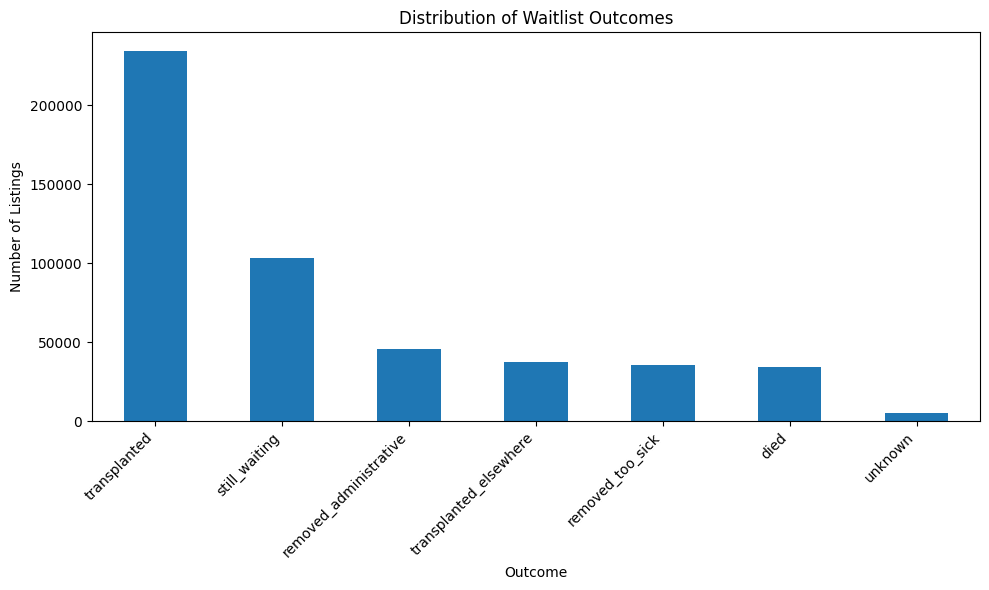

In [ ]:
# Plot the distribution of final waitlist outcomes

outcome_counts = df["outcome"].value_counts()

plt.figure(figsize=(10, 6))

outcome_counts.plot(kind="bar")

plt.title("Distribution of Waitlist Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "outcome_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Waitlist Outcome Distribution

The final waitlist outcomes are not evenly distributed.

- Transplanted: 47.37%
- Still waiting: 20.87%
- Removed administratively: 9.16%
- Transplanted elsewhere: 7.53%
- Removed because too sick: 7.12%
- Died: 6.98%
- Unknown: 0.97%

Nearly half of the waitlist registrations in the analytic cohort resulted in a recorded transplant. Adverse outcomes (`died` and `removed_too_sick`) together represent 14.09% of the dataset.

Because the outcome categories are unevenly distributed, class imbalance will need to be considered during model development and evaluation.

AGE SUMMARY
count    494862.000000
mean         51.874533
std          14.601018
min           0.000000
1%           11.000000
5%           25.000000
25%          43.000000
50%          54.000000
75%          63.000000
95%          71.000000
99%          76.000000
max          91.000000
Name: INIT_AGE, dtype: float64


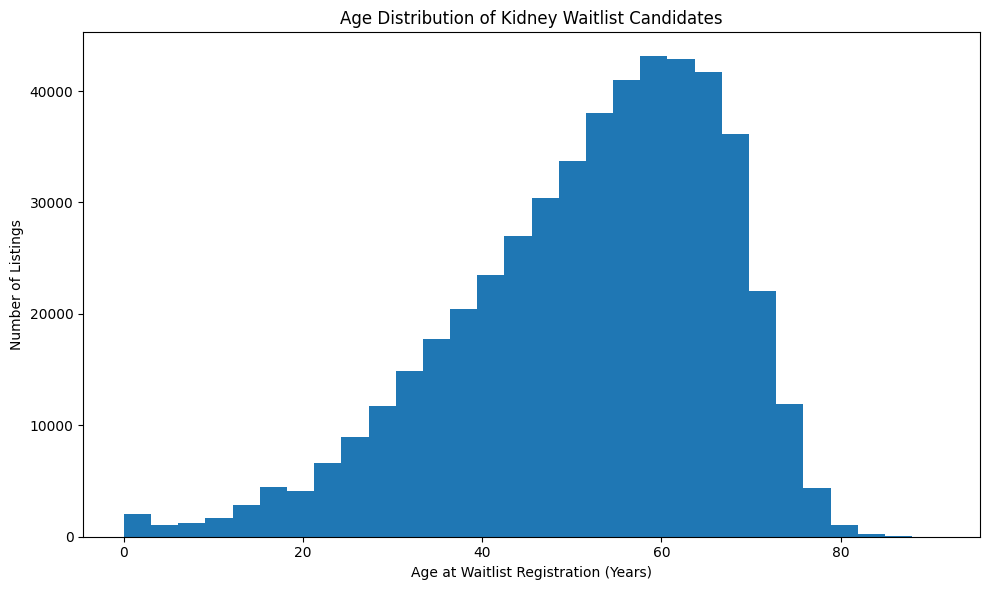

In [ ]:
# Analyze the age distribution of waitlist candidates

print("AGE SUMMARY")
print(
    df["INIT_AGE"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)


# Create age distribution histogram

plt.figure(figsize=(10, 6))

plt.hist(
    df["INIT_AGE"],
    bins=30
)

plt.title("Age Distribution of Kidney Waitlist Candidates")
plt.xlabel("Age at Waitlist Registration (Years)")
plt.ylabel("Number of Listings")

plt.tight_layout()

plt.savefig(
    "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Age Distribution

Candidate age at waitlist registration ranges from 0 to 91 years.

- Mean age: 51.87 years
- Median age: 54 years
- 25th percentile: 43 years
- 75th percentile: 63 years
- 95th percentile: 71 years

The distribution is concentrated primarily among middle-aged and older candidates, although pediatric and younger candidates are also represented. Low ages were retained because they may represent legitimate pediatric transplant candidates rather than data errors.

In [ ]:
# Create descriptive age groups

age_bins = [0, 18, 35, 50, 65, 75, np.inf]

age_labels = [
    "0-17",
    "18-34",
    "35-49",
    "50-64",
    "65-74",
    "75+"
]

df["age_group"] = pd.cut(
    df["INIT_AGE"],
    bins=age_bins,
    labels=age_labels,
    right=False
)


# Calculate adverse outcome statistics by age group

age_adverse_summary = (
    df.groupby("age_group", observed=True)
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

age_adverse_summary["Adverse_Rate"] = (
    age_adverse_summary["Adverse_Rate"] * 100
).round(2)

age_adverse_summary

,age_group,Listings,Adverse_Events,Adverse_Rate
0,0-17,12622,253,2.00
1,18-34,52538,2603,4.95
2,35-49,124321,12245,9.85
3,50-64,201703,33066,16.39
4,65-74,95239,19863,20.86
5,75+,8439,1713,20.30


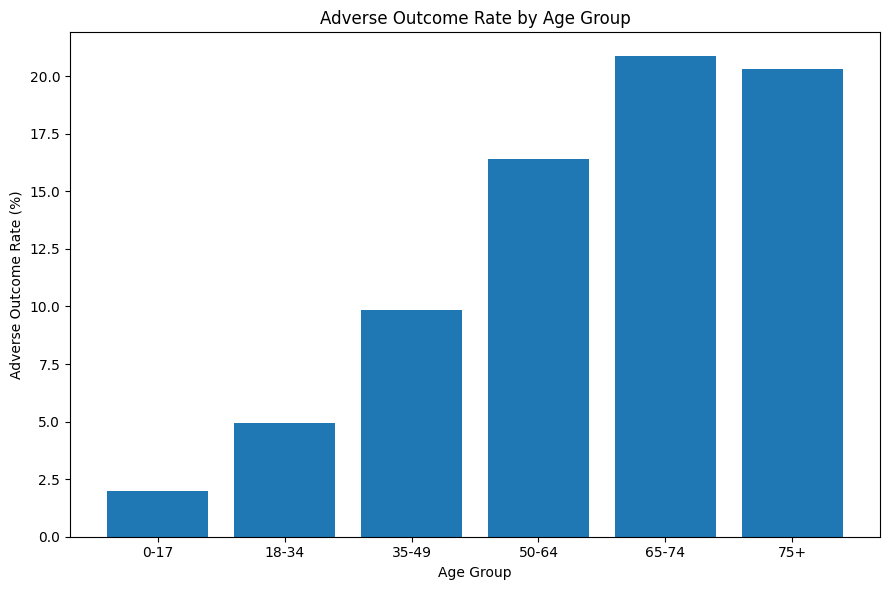

In [ ]:
# Plot adverse outcome rate by age group

plt.figure(figsize=(9, 6))

plt.bar(
    age_adverse_summary["age_group"].astype(str),
    age_adverse_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Age and Adverse Outcomes

The observed adverse-outcome rate differs substantially across age groups.

- Ages 0–17: 2.00%
- Ages 18–34: 4.95%
- Ages 35–49: 9.85%
- Ages 50–64: 16.39%
- Ages 65–74: 20.86%
- Ages 75+: 20.30%

The adverse-outcome rate generally increases across older age groups, with the highest observed rate among candidates ages 65–74.

The 75+ group has a similar adverse rate but contains substantially fewer listings than most other adult age groups. These results describe an association in the dataset and should not be interpreted as evidence that age itself causes adverse outcomes.

Because age is also a planned fairness-analysis variable, model performance should later be evaluated separately across age groups.

In [ ]:
# Analyze gender distribution and adverse outcomes

gender_summary = (
    df.groupby("GENDER")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

# Convert rate to percentage
gender_summary["Adverse_Rate"] = (
    gender_summary["Adverse_Rate"] * 100
).round(2)

# Calculate percentage of total listings
gender_summary["Listing_Percent"] = (
    gender_summary["Listings"] / len(df) * 100
).round(2)

gender_summary

,GENDER,Listings,Adverse_Events,Adverse_Rate,Listing_Percent
0,F,188454,24584,13.05,38.08
1,M,306408,45159,14.74,61.92


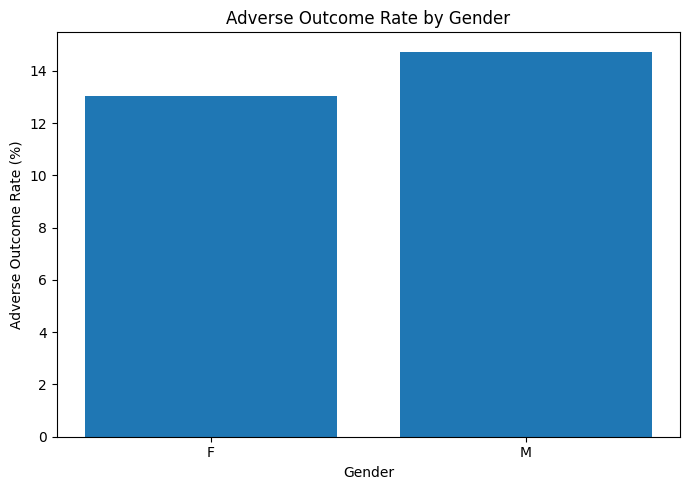

In [ ]:
# Plot adverse outcome rate by gender

plt.figure(figsize=(7, 5))

plt.bar(
    gender_summary["GENDER"],
    gender_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Gender and Adverse Outcomes

The dataset contains more male than female waitlist registrations.

- Female listings: 188,454 (38.08%)
- Male listings: 306,408 (61.92%)

Observed adverse-outcome rates were:

- Female: 13.05%
- Male: 14.74%

Male listings had a somewhat higher observed adverse-outcome rate in this dataset. This difference is descriptive and should not be interpreted as causal because other demographic and clinical characteristics may differ between groups.

Because gender is also relevant to the project's fairness analysis, model performance should later be evaluated separately across gender groups.

In [ ]:
# Analyze ABO blood type distribution and adverse outcomes

abo_summary = (
    df.groupby("ABO")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

abo_summary["Adverse_Rate"] = (
    abo_summary["Adverse_Rate"] * 100
).round(2)

abo_summary["Listing_Percent"] = (
    abo_summary["Listings"] / len(df) * 100
).round(2)

abo_summary = abo_summary.sort_values(
    "Listings",
    ascending=False
)

abo_summary

,ABO,Listings,Adverse_Events,Adverse_Rate,Listing_Percent
7,O,243693,36572,15.01,49.24
0,A,155594,19940,12.82,31.44
6,B,74036,10997,14.85,14.96
5,AB,18475,1858,10.06,3.73
1,A1,2398,287,11.97,0.48
3,A2,365,57,15.62,0.07
2,A1B,226,22,9.73,0.05
4,A2B,75,10,13.33,0.02


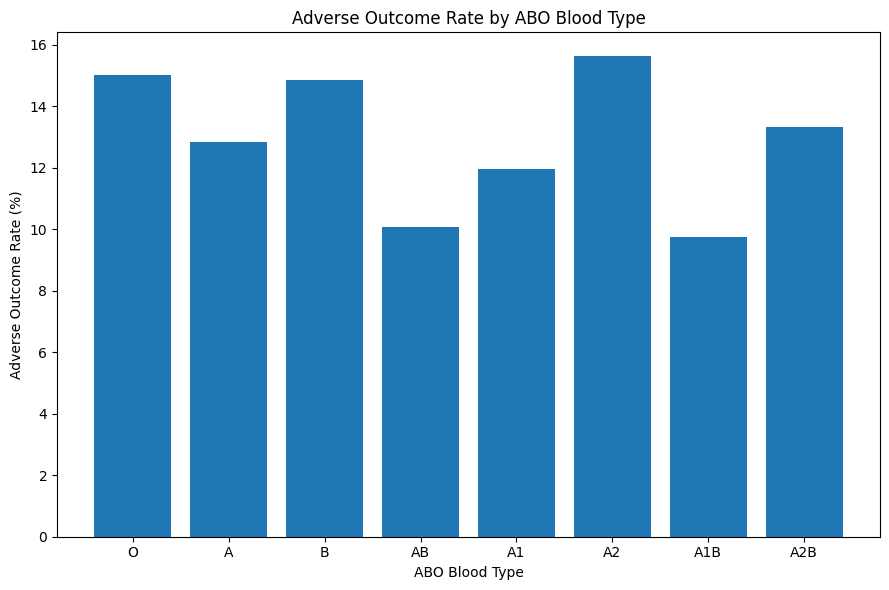

In [ ]:
# Plot adverse outcome rate by ABO blood type

plt.figure(figsize=(9, 6))

plt.bar(
    abo_summary["ABO"],
    abo_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by ABO Blood Type")
plt.xlabel("ABO Blood Type")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_blood_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ABO Blood Type and Adverse Outcomes

Blood type O is the most common blood type in the analytic cohort, followed by A and B.

- O: 243,693 listings (49.24%), adverse rate 15.01%
- A: 155,594 listings (31.44%), adverse rate 12.82%
- B: 74,036 listings (14.96%), adverse rate 14.85%
- AB: 18,475 listings (3.73%), adverse rate 10.06%

Smaller ABO subtypes such as A1, A2, A1B, and A2B represent less than 1% of the dataset individually. Their adverse-outcome rates should therefore be interpreted cautiously because the smaller sample sizes can produce less stable percentages.

Differences in adverse-outcome rates across blood types are descriptive associations and should not be interpreted as causal effects.

In [ ]:
# Analyze OPTN region distribution and adverse outcomes

region_summary = (
    df.groupby("REGION")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

region_summary["Adverse_Rate"] = (
    region_summary["Adverse_Rate"] * 100
).round(2)

region_summary["Listing_Percent"] = (
    region_summary["Listings"] / len(df) * 100
).round(2)

region_summary

,REGION,Listings,Adverse_Events,Adverse_Rate,Listing_Percent
0,1,20410,3460,16.95,4.12
1,2,59797,8916,14.91,12.08
2,3,69493,9721,13.99,14.04
3,4,56511,8791,15.56,11.42
4,5,81578,12231,14.99,16.48
5,6,13816,1722,12.46,2.79
6,7,40881,4732,11.58,8.26
7,8,26070,3091,11.86,5.27
8,9,34543,4680,13.55,6.98
9,10,31783,4342,13.66,6.42


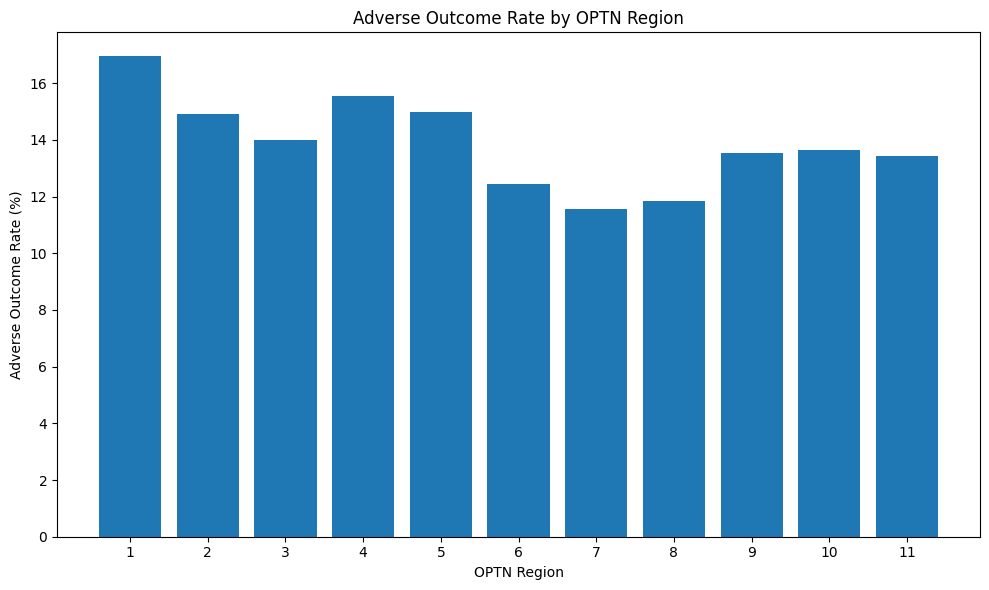

In [ ]:
# Plot adverse outcome rate by OPTN region

plt.figure(figsize=(10, 6))

plt.bar(
    region_summary["REGION"].astype(str),
    region_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by OPTN Region")
plt.xlabel("OPTN Region")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### OPTN Region and Adverse Outcomes

Adverse-outcome rates vary across the 11 OPTN regions.

- Highest observed rate: Region 1 — 16.95%
- Region 4 — 15.56%
- Region 5 — 14.99%
- Region 2 — 14.91%
- Lowest observed rate: Region 7 — 11.58%
- Region 8 — 11.86%

The difference between the highest and lowest observed regional adverse-outcome rates is approximately 5.37 percentage points.

Regional sample sizes also differ substantially. For example, Region 5 contains 81,578 listings, while Region 6 contains 13,816.

These geographic differences are descriptive associations and may reflect differences in candidate characteristics, transplant-center practices, organ availability, allocation patterns, or other system-level factors. Regional effects should therefore be investigated further rather than interpreted causally.

In [ ]:
# Analyze race/ethnicity category distribution and adverse outcomes

ethcat_summary = (
    df.groupby("ETHCAT")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

# Convert adverse rate to percentage
ethcat_summary["Adverse_Rate"] = (
    ethcat_summary["Adverse_Rate"] * 100
).round(2)

# Calculate percentage of total listings
ethcat_summary["Listing_Percent"] = (
    ethcat_summary["Listings"] / len(df) * 100
).round(2)

ethcat_summary

,ETHCAT,Listings,Adverse_Events,Adverse_Rate,Listing_Percent
0,1,202625,29406,14.51,40.95
1,2,144926,20604,14.22,29.29
2,4,97884,13208,13.49,19.78
3,5,36995,4890,13.22,7.48
4,6,3949,672,17.02,0.80
5,7,2522,367,14.55,0.51
6,9,4182,525,12.55,0.85
7,998,1779,71,3.99,0.36


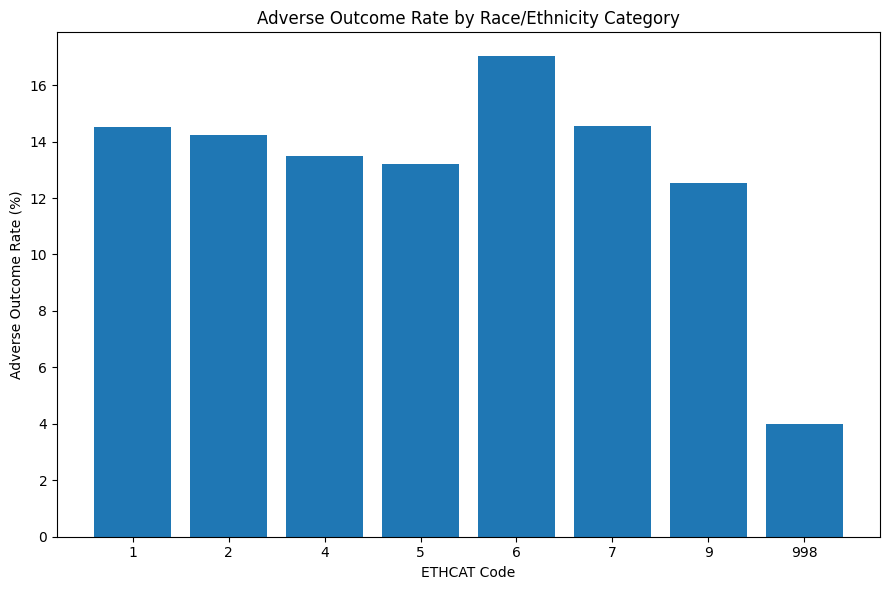

In [ ]:
# Plot adverse outcome rate by race/ethnicity category code

plt.figure(figsize=(9, 6))

plt.bar(
    ethcat_summary["ETHCAT"].astype(str),
    ethcat_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by Race/Ethnicity Category")
plt.xlabel("ETHCAT Code")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_ethcat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Race/Ethnicity Category and Adverse Outcomes

Observed adverse-outcome rates vary across the coded `ETHCAT` categories.

- Code 1: 14.51%
- Code 2: 14.22%
- Code 4: 13.49%
- Code 5: 13.22%
- Code 6: 17.02%
- Code 7: 14.55%
- Code 9: 12.55%
- Code 998: 3.99%

The category sizes differ substantially. Codes 1, 2, and 4 represent most of the dataset, while several other categories contain relatively few listings.

The official meanings of the `ETHCAT` numeric codes have not yet been verified from the OPTN data dictionary. Therefore, the codes are reported without assigning demographic labels.

These differences are descriptive associations only. Because race/ethnicity is an important fairness variable, later model evaluation should compare predictive performance across verified demographic groups rather than relying only on overall model performance.

In [ ]:
# Analyze dialysis status and adverse outcomes

dialysis_summary = (
    df.groupby("ON_DIALYSIS")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

dialysis_summary["Adverse_Rate"] = (
    dialysis_summary["Adverse_Rate"] * 100
).round(2)

dialysis_summary["Listing_Percent"] = (
    dialysis_summary["Listings"] / len(df) * 100
).round(2)

dialysis_summary

,ON_DIALYSIS,Listings,Adverse_Events,Adverse_Rate,Listing_Percent
0,N,134245,13798,10.28,27.13
1,Y,360617,55945,15.51,72.87


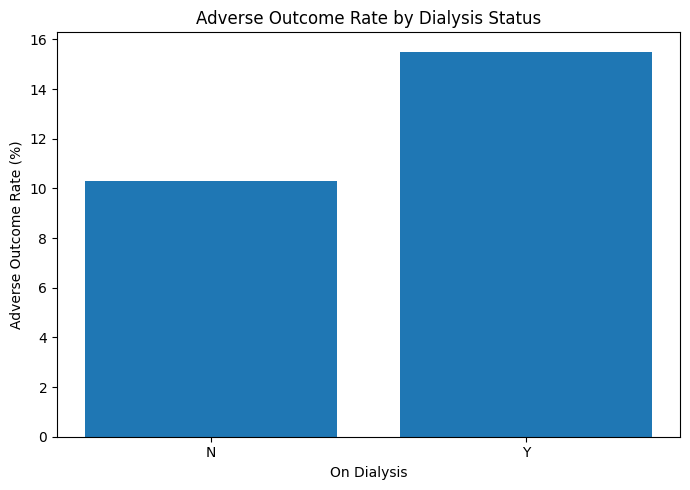

In [ ]:
# Plot adverse outcome rate by dialysis status

plt.figure(figsize=(7, 5))

plt.bar(
    dialysis_summary["ON_DIALYSIS"],
    dialysis_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by Dialysis Status")
plt.xlabel("On Dialysis")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_dialysis_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Dialysis Status and Adverse Outcomes

Most candidates in the analytic cohort were recorded as being on dialysis at the time represented by this variable.

- On dialysis: 360,617 listings (72.87%)
  - Adverse-outcome rate: 15.51%
- Not on dialysis: 134,245 listings (27.13%)
  - Adverse-outcome rate: 10.28%

Candidates recorded as being on dialysis had an observed adverse-outcome rate approximately 5.23 percentage points higher than candidates not recorded as being on dialysis.

This is a descriptive association and should not be interpreted as a causal effect. Dialysis status may also be associated with age, disease severity, duration of kidney disease, and other clinical characteristics.

In [ ]:
# Analyze the overall time-to-event distribution

print("TIME-TO-EVENT SUMMARY")

print(
    df["days_to_event"].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

TIME-TO-EVENT SUMMARY
count    494803.000000
mean        649.541492
std         654.237636
min           0.000000
1%            3.000000
5%           15.000000
25%         144.000000
50%         433.000000
75%         965.000000
95%        1989.000000
99%        2808.000000
max        4200.000000
Name: days_to_event, dtype: float64


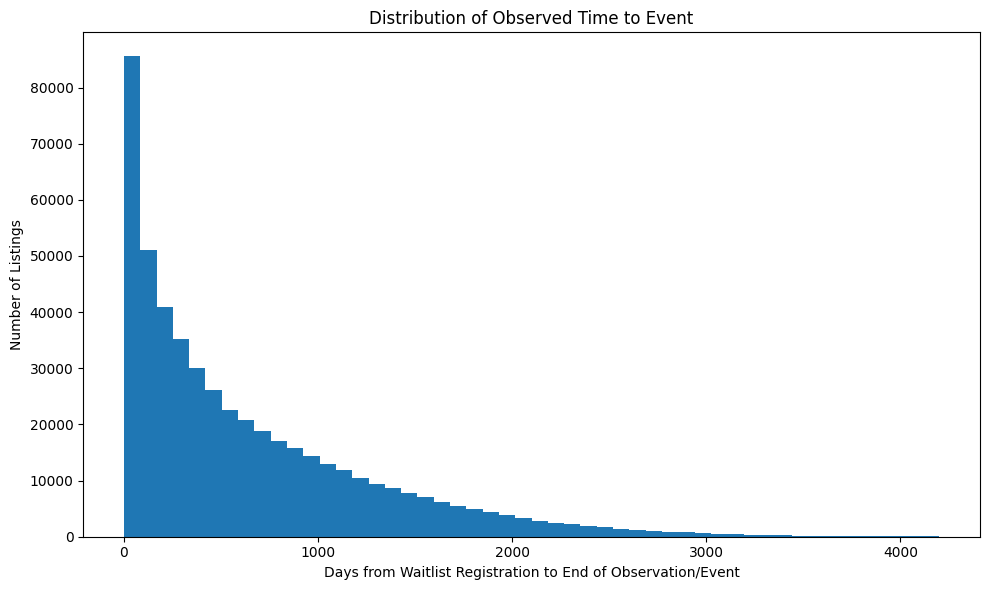

In [ ]:
# Plot the distribution of observed time-to-event

plt.figure(figsize=(10, 6))

plt.hist(
    df["days_to_event"].dropna(),
    bins=50
)

plt.title("Distribution of Observed Time to Event")
plt.xlabel("Days from Waitlist Registration to End of Observation/Event")
plt.ylabel("Number of Listings")

plt.tight_layout()

plt.savefig(
    "time_to_event_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observed Time-to-Event Distribution

The observed time-to-event variable is strongly right-skewed.

- Mean observed duration: 649.54 days
- Median observed duration: 433 days
- 25th percentile: 144 days
- 75th percentile: 965 days
- 95th percentile: 1,989 days
- 99th percentile: 2,808 days
- Maximum: 4,200 days

The mean is substantially higher than the median because a smaller number of listings have very long observation periods.

Because `days_to_event` includes transplant events, competing outcomes, and censored observations, it should not be interpreted simply as "time to transplant" for every record. Survival-analysis methods will be needed to appropriately account for event type and censoring.

In [ ]:
# Compare median observed time-to-event across outcome groups

median_time_by_outcome = (
    df.groupby("outcome")["days_to_event"]
    .median()
    .sort_values(ascending=False)
)

median_time_by_outcome

,days_to_event
outcome,
removed_too_sick,805.0
removed_administrative,736.0
unknown,700.0
died,697.0
still_waiting,520.0
transplanted_elsewhere,503.0
transplanted,249.0


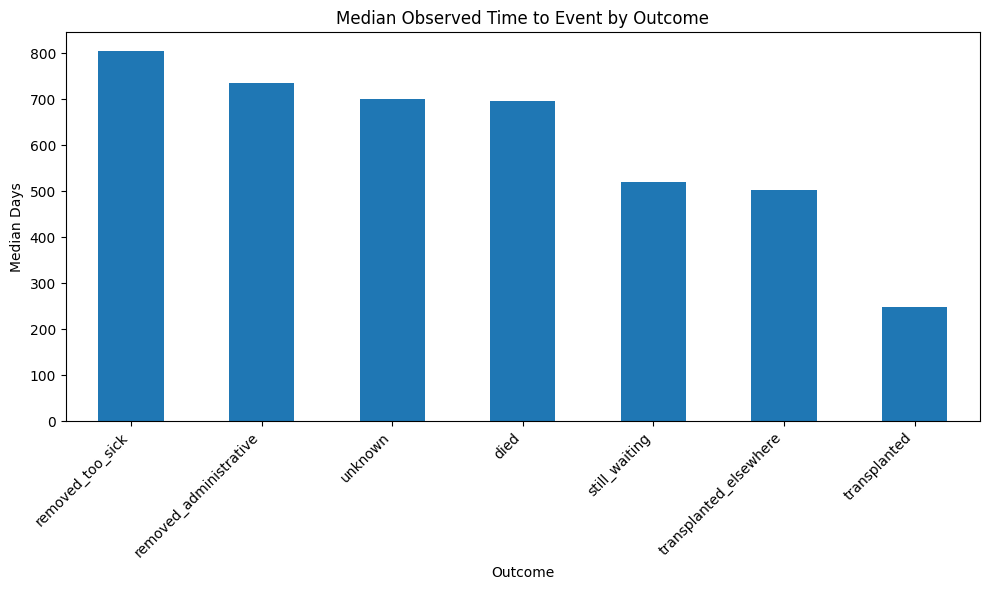

In [ ]:
# Plot median observed time-to-event by outcome

plt.figure(figsize=(10, 6))

median_time_by_outcome.plot(kind="bar")

plt.title("Median Observed Time to Event by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Median Days")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "median_time_to_event_by_outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observed Time to Event by Final Outcome

Median observed time-to-event differs across final outcome groups.

- Transplanted: 249 days
- Transplanted elsewhere: 503 days
- Still waiting: 520 days
- Died: 697 days
- Unknown: 700 days
- Removed administratively: 736 days
- Removed too sick: 805 days

Listings ending in a recorded transplant had the shortest median observed duration, while listings ending in removal because the candidate became too sick had the longest median duration.

These are descriptive differences only. Because transplant, death, removal, and censoring are competing or different types of outcomes, these results should not be interpreted as evidence that longer waiting time causes a particular outcome.

In [ ]:
# Analyze the distribution of initial CPRA

print("INITIAL CPRA SUMMARY")

print(
    df["INIT_CPRA"].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print(
    "\nMissing INIT_CPRA values:",
    df["INIT_CPRA"].isna().sum()
)

print(
    "Missing percentage:",
    round(df["INIT_CPRA"].isna().mean() * 100, 2),
    "%"
)

print(
    "\nCandidates with INIT_CPRA = 0:",
    (df["INIT_CPRA"] == 0).sum()
)

print(
    "Candidates with INIT_CPRA > 0:",
    (df["INIT_CPRA"] > 0).sum()
)

INITIAL CPRA SUMMARY
count    352121.000000
mean          9.786130
std          24.799939
min           0.000000
1%            0.000000
5%            0.000000
25%           0.000000
50%           0.000000
75%           0.000000
90%          46.860000
95%          82.770000
99%          99.780000
max         100.000000
Name: INIT_CPRA, dtype: float64

Missing INIT_CPRA values: 142741
Missing percentage: 28.84 %

Candidates with INIT_CPRA = 0: 277468
Candidates with INIT_CPRA > 0: 74653


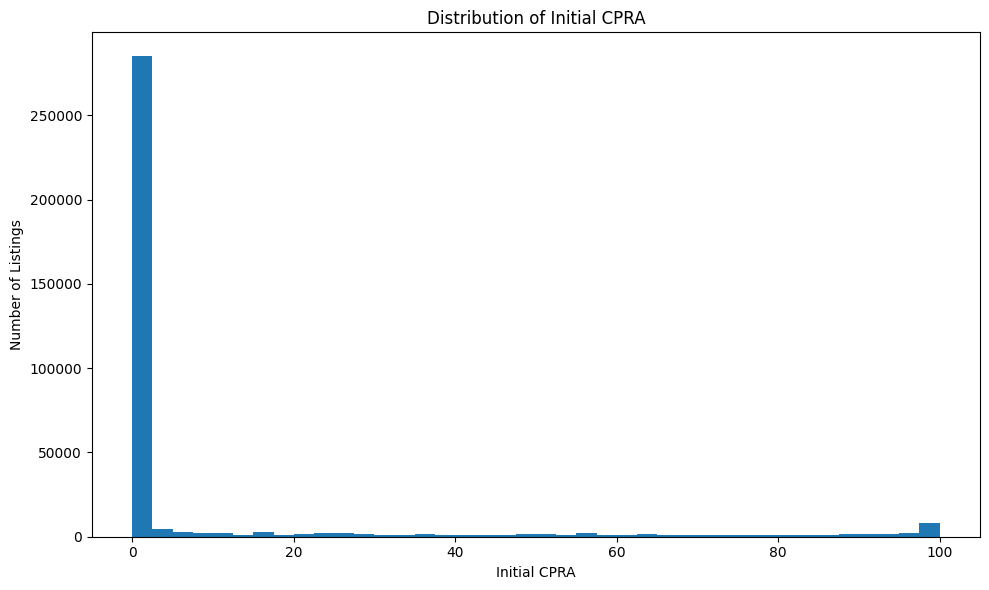

In [ ]:
# Plot the distribution of non-missing initial CPRA values

plt.figure(figsize=(10, 6))

plt.hist(
    df["INIT_CPRA"].dropna(),
    bins=40
)

plt.title("Distribution of Initial CPRA")
plt.xlabel("Initial CPRA")
plt.ylabel("Number of Listings")

plt.tight_layout()

plt.savefig(
    "initial_cpra_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Initial CPRA Distribution

`INIT_CPRA` has a highly concentrated and non-normal distribution.

- Non-missing observations: 352,121
- Missing observations: 142,741 (28.84%)
- CPRA = 0: 277,468 listings
- CPRA > 0: 74,653 listings
- Median: 0
- 75th percentile: 0
- 90th percentile: 46.86
- 95th percentile: 82.77
- 99th percentile: 99.78
- Observed range: 0–100

Approximately 78.8% of non-missing initial CPRA values are exactly zero. This explains why the earlier IQR method labeled all positive CPRA values as statistical outliers: the interquartile range was zero.

Positive CPRA values should therefore not be treated as data errors or automatically removed. Missing CPRA values will also need separate consideration during preprocessing.

In [ ]:
# Examine adverse outcomes across descriptive INIT_CPRA ranges

cpra_eda = df.loc[
    df["INIT_CPRA"].notna(),
    ["INIT_CPRA", "event_adverse"]
].copy()

cpra_bins = [-0.001, 0, 20, 50, 80, 100]

cpra_labels = [
    "0",
    ">0-20",
    ">20-50",
    ">50-80",
    ">80-100"
]

cpra_eda["CPRA_Group"] = pd.cut(
    cpra_eda["INIT_CPRA"],
    bins=cpra_bins,
    labels=cpra_labels,
    right=True
)

cpra_adverse_summary = (
    cpra_eda.groupby("CPRA_Group", observed=True)
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

cpra_adverse_summary["Adverse_Rate"] = (
    cpra_adverse_summary["Adverse_Rate"] * 100
).round(2)

cpra_adverse_summary

,CPRA_Group,Listings,Adverse_Events,Adverse_Rate
0,0,277468,51537,18.57
1,>0-20,23711,3072,12.96
2,>20-50,17575,2244,12.77
3,>50-80,14600,1953,13.38
4,>80-100,18767,2647,14.10


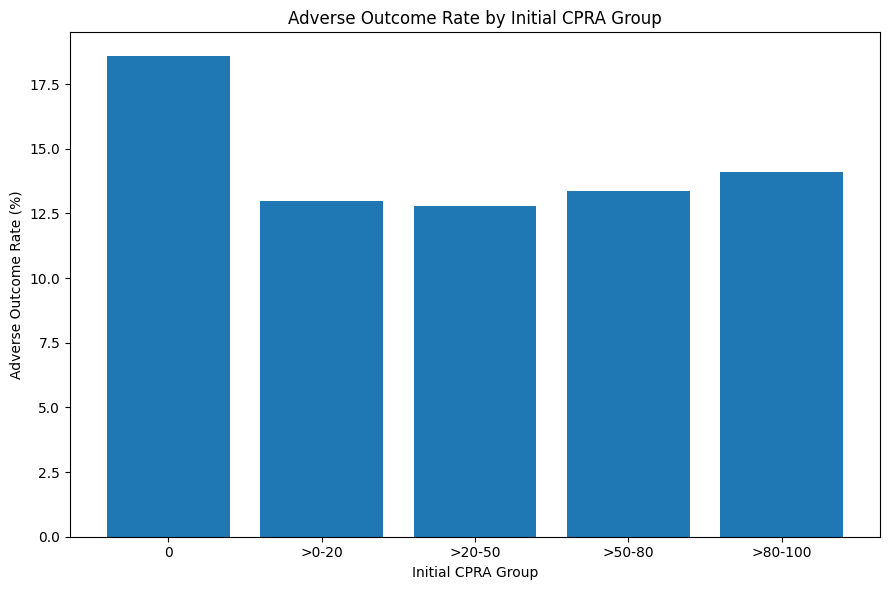

In [ ]:
# Plot adverse outcome rate by initial CPRA group

plt.figure(figsize=(9, 6))

plt.bar(
    cpra_adverse_summary["CPRA_Group"].astype(str),
    cpra_adverse_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate by Initial CPRA Group")
plt.xlabel("Initial CPRA Group")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_initial_cpra.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Initial CPRA and Adverse Outcomes

Among listings with a recorded initial CPRA, adverse-outcome rates differed across descriptive CPRA groups.

- CPRA = 0: 18.57%
- CPRA >0–20: 12.96%
- CPRA >20–50: 12.77%
- CPRA >50–80: 13.38%
- CPRA >80–100: 14.10%

The CPRA = 0 group contains the majority of non-missing observations and has the highest observed adverse-outcome rate.

This relationship is descriptive only. It should not be interpreted as evidence that a CPRA value of zero causes worse outcomes because other candidate characteristics and missingness patterns may differ across CPRA groups.

Initial CPRA is missing for 28.84% of all listings, so its missing-data mechanism will also need consideration during preprocessing.

In [ ]:
# Examine the central BMI distribution for visualization

bmi_non_missing = df["BMI_TCR"].dropna()

bmi_p1 = bmi_non_missing.quantile(0.01)
bmi_p99 = bmi_non_missing.quantile(0.99)

print("1st percentile BMI:", round(bmi_p1, 2))
print("99th percentile BMI:", round(bmi_p99, 2))

bmi_central = bmi_non_missing[
    bmi_non_missing.between(bmi_p1, bmi_p99)
]

print("\nTotal non-missing BMI values:", len(bmi_non_missing))
print("Values shown in central 98%:", len(bmi_central))
print("Values outside visualization range:",
      len(bmi_non_missing) - len(bmi_central))

print("\nCENTRAL BMI SUMMARY")
print(bmi_central.describe())

1st percentile BMI: 16.69
99th percentile BMI: 42.52

Total non-missing BMI values: 493304
Values shown in central 98%: 483465
Values outside visualization range: 9839

CENTRAL BMI SUMMARY
count    483465.000000
mean         28.799550
std           5.413407
min          16.690000
25%          24.730000
50%          28.530000
75%          32.750000
max          42.520000
Name: BMI_TCR, dtype: float64


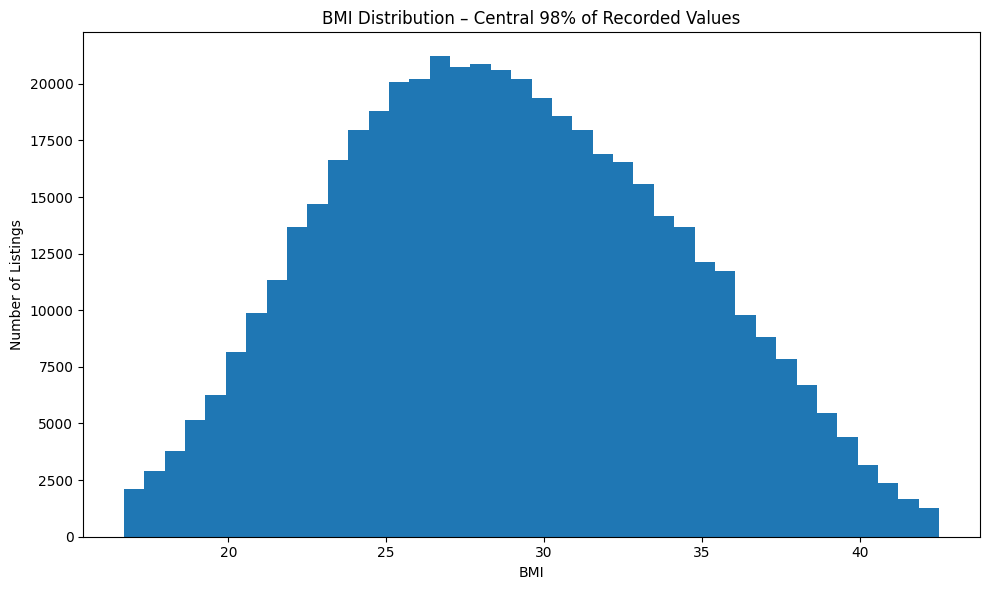

In [ ]:
# Plot the central 98% of recorded BMI values

plt.figure(figsize=(10, 6))

plt.hist(
    bmi_central,
    bins=40
)

plt.title("BMI Distribution – Central 98% of Recorded Values")
plt.xlabel("BMI")
plt.ylabel("Number of Listings")

plt.tight_layout()

plt.savefig(
    "bmi_distribution_central_98_percent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### BMI Distribution

The raw `BMI_TCR` variable contains extreme anomalous values that make an unfiltered histogram difficult to interpret. Therefore, the BMI distribution was visualized using only the central 98% of recorded values (1st through 99th percentiles) without modifying the underlying dataset.

For the central 98%:

- 1st percentile: 16.69
- 99th percentile: 42.52
- Mean: 28.80
- Median: 28.53
- 25th percentile: 24.73
- 75th percentile: 32.75

A total of 9,839 recorded BMI values fall outside the visualization range. These observations were excluded from the visualization only and remain in the original dataset.

Because some raw BMI values are extremely implausible, BMI requires a documented data-quality treatment before it is used as a model feature.

In [ ]:
# Examine adverse outcomes across BMI quartiles
# using only the central 98% for this exploratory comparison

bmi_eda = df.loc[
    df["BMI_TCR"].between(bmi_p1, bmi_p99),
    ["BMI_TCR", "event_adverse"]
].copy()

bmi_eda["BMI_Quartile"] = pd.qcut(
    bmi_eda["BMI_TCR"],
    q=4,
    labels=[
        "Q1 (Lowest)",
        "Q2",
        "Q3",
        "Q4 (Highest)"
    ]
)

bmi_adverse_summary = (
    bmi_eda.groupby("BMI_Quartile", observed=True)
    .agg(
        Listings=("event_adverse", "size"),
        Median_BMI=("BMI_TCR", "median"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

bmi_adverse_summary["Adverse_Rate"] = (
    bmi_adverse_summary["Adverse_Rate"] * 100
).round(2)

bmi_adverse_summary["Median_BMI"] = (
    bmi_adverse_summary["Median_BMI"].round(2)
)

bmi_adverse_summary

,BMI_Quartile,Listings,Median_BMI,Adverse_Events,Adverse_Rate
0,Q1 (Lowest),120876,22.39,14925,12.35
1,Q2,121126,26.65,17117,14.13
2,Q3,120730,30.52,18339,15.19
3,Q4 (Highest),120733,35.56,18111,15.00


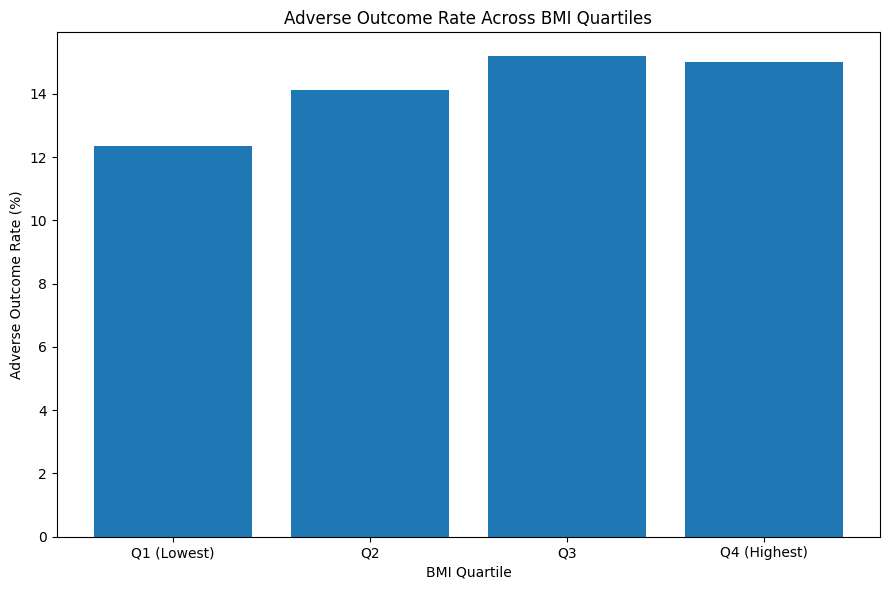

In [ ]:
# Plot adverse outcome rate across BMI quartiles

plt.figure(figsize=(9, 6))

plt.bar(
    bmi_adverse_summary["BMI_Quartile"].astype(str),
    bmi_adverse_summary["Adverse_Rate"]
)

plt.title("Adverse Outcome Rate Across BMI Quartiles")
plt.xlabel("BMI Quartile")
plt.ylabel("Adverse Outcome Rate (%)")

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_bmi_quartile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### BMI and Adverse Outcomes

For exploratory analysis, BMI observations between the 1st and 99th percentiles were divided into four approximately equal-sized groups.

Observed adverse-outcome rates were:

- Q1 (median BMI 22.39): 12.35%
- Q2 (median BMI 26.65): 14.13%
- Q3 (median BMI 30.52): 15.19%
- Q4 (median BMI 35.56): 15.00%

Higher BMI quartiles generally had higher observed adverse-outcome rates than the lowest BMI quartile, although the relationship was not strictly increasing.

This analysis excludes the outer 2% of BMI values only for exploratory comparison because the raw variable contains extreme data-quality anomalies. No BMI observations have been removed from the original dataset.

The observed relationship is descriptive and should not be interpreted as evidence that BMI causes adverse waitlist outcomes.

In [ ]:
# Create listing year from INIT_DATE

df["listing_year"] = pd.to_datetime(
    df["INIT_DATE"]
).dt.year

print("Listing years:")
print(sorted(df["listing_year"].unique()))

Listing years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


In [ ]:
# Analyze listings and adverse-outcome rates by listing year

year_summary = (
    df.groupby("listing_year")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Events=("event_adverse", "sum"),
        Adverse_Rate=("event_adverse", "mean")
    )
    .reset_index()
)

year_summary["Adverse_Rate"] = (
    year_summary["Adverse_Rate"] * 100
).round(2)

year_summary

,listing_year,Listings,Adverse_Events,Adverse_Rate
0,2015,36599,8321,22.74
1,2016,36956,7880,21.32
2,2017,37209,7529,20.23
3,2018,40564,7915,19.51
4,2019,43223,8306,19.22
5,2020,37825,6841,18.09
6,2021,42130,6637,15.75
7,2022,44442,5880,13.23
8,2023,47003,4809,10.23
9,2024,49635,3632,7.32


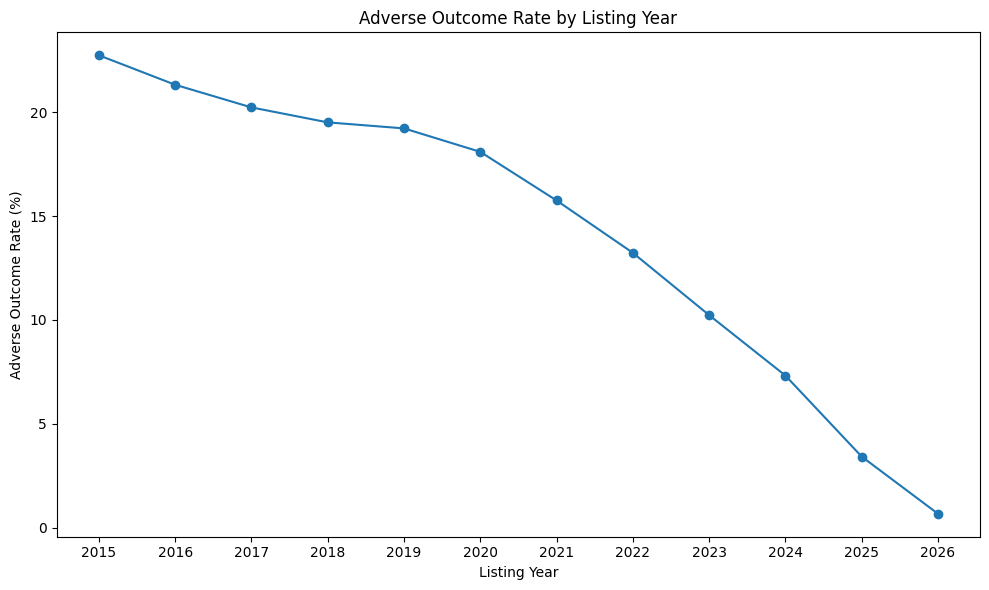

In [ ]:
# Plot adverse-outcome rate by listing year

plt.figure(figsize=(10, 6))

plt.plot(
    year_summary["listing_year"],
    year_summary["Adverse_Rate"],
    marker="o"
)

plt.title("Adverse Outcome Rate by Listing Year")
plt.xlabel("Listing Year")
plt.ylabel("Adverse Outcome Rate (%)")

plt.xticks(year_summary["listing_year"])

plt.tight_layout()

plt.savefig(
    "adverse_rate_by_listing_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Outcome Patterns Across Listing Years

The observed adverse-outcome rate decreases substantially across more recent listing years, from 22.74% among 2015 listings to 0.67% among 2026 listings.

This pattern should not be interpreted directly as evidence that waitlist outcomes improved over time.

Candidates listed in earlier years have had substantially more time for an adverse event to occur, while candidates listed in recent years have much shorter follow-up and may still be waiting. The 2026 cohort is also incomplete because the analytic dataset only includes listings through June 2026.

Therefore, differences across listing years may reflect a combination of:

- unequal follow-up duration,
- right censoring,
- changes in the candidate population,
- changes in transplant and allocation practices,
- and true changes in outcomes over time.

Time and policy-era effects should be considered carefully during model development and evaluation.

In [ ]:
# Examine censoring and follow-up time by listing year

year_followup_summary = (
    df.groupby("listing_year")
    .agg(
        Listings=("event_adverse", "size"),
        Adverse_Rate=("event_adverse", "mean"),
        Censoring_Rate=("censored", "mean"),
        Still_Waiting=("censored", "sum"),
        Median_Followup_Days=("days_to_event", "median")
    )
    .reset_index()
)

year_followup_summary["Adverse_Rate"] = (
    year_followup_summary["Adverse_Rate"] * 100
).round(2)

year_followup_summary["Censoring_Rate"] = (
    year_followup_summary["Censoring_Rate"] * 100
).round(2)

year_followup_summary["Median_Followup_Days"] = (
    year_followup_summary["Median_Followup_Days"].round(1)
)

year_followup_summary

,listing_year,Listings,Adverse_Rate,Censoring_Rate,Still_Waiting,Median_Followup_Days
0,2015,36599,22.74,0.75,275,737.0
1,2016,36956,21.32,1.17,432,700.0
2,2017,37209,20.23,1.77,657,654.0
3,2018,40564,19.51,2.60,1055,629.0
4,2019,43223,19.22,4.07,1761,610.0
5,2020,37825,18.09,6.57,2485,563.0
6,2021,42130,15.75,10.80,4551,538.0
7,2022,44442,13.23,16.90,7512,506.0
8,2023,47003,10.23,25.79,12120,470.0
9,2024,49635,7.32,38.66,19189,474.0


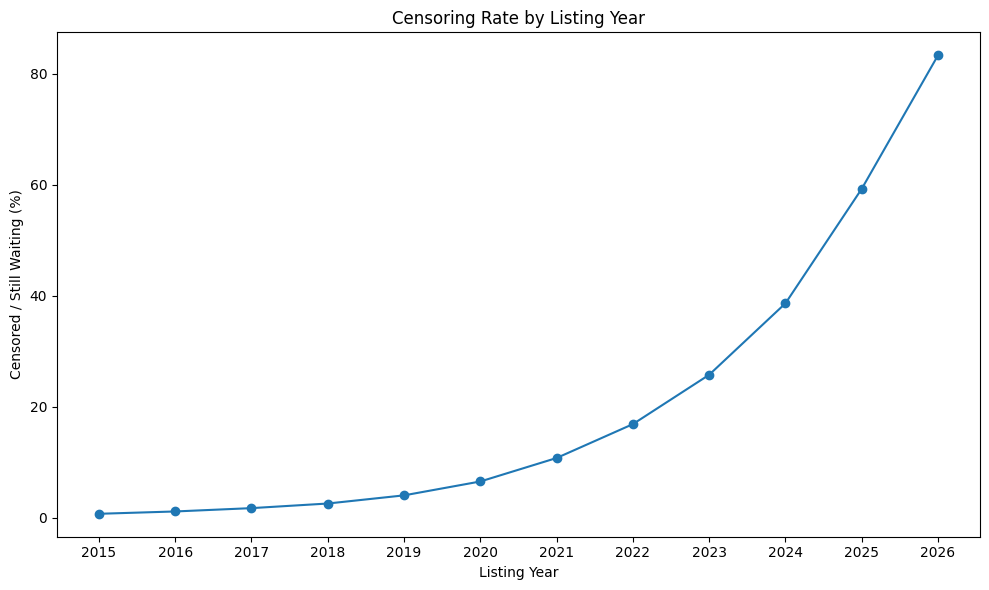

In [ ]:
# Plot censoring rate by listing year

plt.figure(figsize=(10, 6))

plt.plot(
    year_followup_summary["listing_year"],
    year_followup_summary["Censoring_Rate"],
    marker="o"
)

plt.title("Censoring Rate by Listing Year")
plt.xlabel("Listing Year")
plt.ylabel("Censored / Still Waiting (%)")

plt.xticks(year_followup_summary["listing_year"])

plt.tight_layout()

plt.savefig(
    "censoring_rate_by_listing_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Follow-Up Time and Censoring Across Listing Years

The decline in raw adverse-outcome rates across recent listing years is strongly associated with shorter follow-up and increased censoring.

Examples include:

- 2015:
  - Adverse-outcome rate: 22.74%
  - Censoring rate: 0.75%
  - Median follow-up: 737 days

- 2022:
  - Adverse-outcome rate: 13.23%
  - Censoring rate: 16.90%
  - Median follow-up: 506 days

- 2025:
  - Adverse-outcome rate: 3.42%
  - Censoring rate: 59.29%
  - Median follow-up: 269 days

- 2026:
  - Adverse-outcome rate: 0.67%
  - Censoring rate: 83.34%
  - Median follow-up: 74 days

This confirms that raw outcome rates across listing years are not directly comparable because recent cohorts have substantially less opportunity for outcomes to occur.

Time-to-event methods that properly account for censoring will therefore be necessary. Listing year and follow-up structure should also be considered when designing model validation and train/test splitting.

In [ ]:
# Creating the September preprocessing plan

preprocessing_plan = pd.DataFrame({

    "Area": [
        "Identifiers",
        "Patient-level duplicates",
        "Dates",
        "Categorical variables",
        "Numerical variables",
        "BMI anomalies",
        "Missing values",
        "Structural missingness",
        "High-missingness variables",
        "Class imbalance",
        "Censoring",
        "Competing risks",
        "Data leakage",
        "Temporal effects",
        "Fairness variables"
    ],

    "Plan": [

        "Exclude identifiers such as WL_ID_CODE, TRR_ID_CODE, and DONOR_ID from model features. Retain PT_CODE only for grouped train/test splitting.",

        "Ensure multiple listings belonging to the same PT_CODE are kept within the same train, validation, or test partition to reduce patient-level leakage.",

        "Convert date columns to datetime format. Use baseline dates only for appropriate feature engineering. Do not use END_DATE, TX_DATE, or COMPOSITE_DEATH_DATE as baseline predictors.",

        "Treat coded variables such as REGION, ETHCAT, INIT_STAT, FUNC_STAT_TCR, ABO, and similar fields as categorical rather than continuous numerical values. Encode them during modeling after code definitions are confirmed.",

        "Keep meaningful continuous variables such as INIT_AGE, INIT_CPRA, and cleaned BMI as numerical features. Apply scaling only when required by the selected model.",

        "Investigate and flag implausible BMI values before modeling. Do not automatically remove all statistical IQR outliers because some extreme but valid BMI observations may exist.",

        "Handle missing values according to each variable's meaning rather than applying one universal imputation rule. Imputation strategies will be learned using training data only.",

        "Preserve structurally missing values where appropriate. Examples include DIALYSIS_DATE for candidates not on dialysis and REM_CD for candidates still waiting.",

        "Review variables with very high missingness such as A2A2B_ELIGIBILITY and MULTIORG before including them. Consider applicability indicators or exclusion depending on documentation and modeling value.",

        "Because event_adverse has a 14.09% positive rate, evaluate class weighting and other imbalance-aware approaches. Do not rely on accuracy alone; emphasize PR-AUC, ROC-AUC, Brier score, and calibration.",

        "Use survival-analysis methods that explicitly account for right censoring rather than treating still-waiting candidates as ordinary negative outcomes.",

        "Treat death and removal-too-sick as competing outcomes when modeling time to transplant. Confirm handling of removed_administrative, transplanted_elsewhere, and unknown outcomes before final survival modeling.",

        "Exclude variables that contain future or outcome information, including REM_CD, END_STAT, END_CPRA, END_DATE, TX_DATE, COMPOSITE_DEATH_DATE, days_to_event, and target variables when constructing baseline predictors.",

        "Account for strong differences in follow-up by listing year. Consider temporal or out-of-time validation because recent cohorts have substantially higher censoring and shorter follow-up.",

        "Retain age, gender, ETHCAT, ABO, and REGION for subgroup/fairness evaluation. Compare model discrimination, calibration, and error rates across relevant groups."
    ]
})

preprocessing_plan

,Area,Plan
0,Identifiers,"Exclude identifiers such as WL_ID_CODE, TRR_ID..."
1,Patient-level duplicates,Ensure multiple listings belonging to the same...
2,Dates,Convert date columns to datetime format. Use b...
3,Categorical variables,"Treat coded variables such as REGION, ETHCAT, ..."
4,Numerical variables,Keep meaningful continuous variables such as I...
5,BMI anomalies,Investigate and flag implausible BMI values be...
6,Missing values,Handle missing values according to each variab...
7,Structural missingness,Preserve structurally missing values where app...
8,High-missingness variables,Review variables with very high missingness su...
9,Class imbalance,Because event_adverse has a 14.09% positive ra...


## Task #8 – Preprocessing Plan

A preliminary preprocessing plan was created based on the September data-quality analysis and EDA.

### Identifiers and Data Splitting
- Patient, waitlist, transplant-registration, and donor identifiers will not be used as predictive features.
- `PT_CODE` will be retained for data splitting because some patients have multiple waitlist registrations.
- Listings belonging to the same patient should remain in the same train, validation, or test partition to reduce patient-level data leakage.

### Missing Values
- Missing values will not be handled with one universal strategy.
- Structural missingness will be preserved where appropriate.
- `DIALYSIS_DATE` is structurally missing for candidates not recorded as being on dialysis.
- `REM_CD` is structurally missing for candidates who are still waiting.
- Transplant-related fields share a common conditional missingness pattern.
- Variables with very high missingness, including `A2A2B_ELIGIBILITY` and `MULTIORG`, require further review before inclusion.
- Any imputation parameters will be learned from training data only.

### Categorical Variables
- Variables such as `REGION`, `ETHCAT`, `INIT_STAT`, `FUNC_STAT_TCR`, `ABO`, and other coded fields will be treated as categorical rather than continuous numerical variables.
- Their exact code meanings will be confirmed using official OPTN documentation before final encoding.
- Appropriate categorical encoding will be performed during modeling.

### Numerical Variables
- Variables such as age, CPRA, BMI, and appropriate waiting-time measures will remain numerical where conceptually appropriate.
- Scaling will only be applied when required by the selected model.

### BMI Data Quality
- `BMI_TCR` contains a small number of extremely implausible values.
- These values will be flagged and investigated before modeling.
- Statistical IQR outliers will not automatically be removed because statistical rarity does not necessarily indicate invalid data.

### Class Imbalance
- The primary adverse-event target has a positive rate of 14.09%.
- Accuracy alone will not be used to evaluate classification performance.
- Class weighting and other imbalance-aware approaches will be evaluated.
- Evaluation will emphasize PR-AUC, ROC-AUC, Brier score, and calibration.

### Censoring and Competing Risks
- Candidates who are still waiting will be handled as right-censored observations for time-to-event analysis.
- Death and removal because the candidate became too sick will be treated as competing outcomes when modeling time to transplant.
- The treatment of `removed_administrative`, `transplanted_elsewhere`, and `unknown` will be confirmed before final survival modeling.

### Data Leakage
Variables containing information known only after listing or near the final outcome will not be used as baseline predictors. Examples include:

- `REM_CD`
- `END_STAT`
- `END_CPRA`
- `END_DATE`
- `TX_DATE`
- `COMPOSITE_DEATH_DATE`
- `days_to_event`
- derived target variables

Additional transplant-related fields will be reviewed based on when the information becomes available.

### Temporal Effects
Recent listing cohorts have substantially shorter follow-up and much higher censoring.

For example:
- 2015 censoring rate: 0.75%
- 2025 censoring rate: 59.29%
- 2026 censoring rate: 83.34%

Therefore, random row-level splitting alone may produce misleading evaluation results. Temporal or out-of-time validation should be considered during model development.

### Fairness
Age, gender, race/ethnicity, blood type, and OPTN region will be retained for subgroup analysis.

Model performance should later be evaluated across relevant subgroups using discrimination, calibration, and error-based metrics rather than relying only on overall performance.

In [ ]:
# Save the preliminary preprocessing plan

preprocessing_plan.to_csv(
    "preprocessing_plan.csv",
    index=False
)

print("Preprocessing plan saved successfully!")
print("File name: preprocessing_plan.csv")
print("Rows:", len(preprocessing_plan))

Preprocessing plan saved successfully!
File name: preprocessing_plan.csv
Rows: 15


In [ ]:
# Create a summary of the main September findings

september_findings = pd.DataFrame({

    "Topic": [
        "Dataset size",
        "Unit of observation",
        "Patient duplication",
        "Outcome distribution",
        "Adverse-event target",
        "Age pattern",
        "Gender pattern",
        "Blood type pattern",
        "Regional pattern",
        "Dialysis pattern",
        "Time-to-event",
        "CPRA pattern",
        "BMI quality issue",
        "Missingness",
        "Temporal censoring",
        "Leakage risk"
    ],

    "Finding": [

        "The analytic dataset contains 494,862 waitlist registrations and 38 variables.",

        "WL_ID_CODE is unique for every row, indicating that each row represents a waitlist registration rather than necessarily one unique patient.",

        "There are 414,187 unique PT_CODE values, meaning some patients have multiple waitlist registrations. Patient-level grouping should be considered during data splitting.",

        "The largest outcome category is transplanted (47.37%), followed by still_waiting (20.87%).",

        "The primary adverse-event target includes death and removal-too-sick. Adverse events represent 14.09% of listings, creating substantial class imbalance.",

        "Observed adverse-event rates generally increase across older age groups, from 2.00% among ages 0-17 to approximately 20% among candidates age 65 and older.",

        "Male listings represent 61.92% of the cohort and have an observed adverse rate of 14.74%, compared with 13.05% for female listings.",

        "Blood type O is the largest ABO group (49.24%) and has an observed adverse rate of 15.01%. Smaller ABO subtypes should be interpreted cautiously due to small sample sizes.",

        "Observed adverse-event rates vary across OPTN regions, ranging from 11.58% in Region 7 to 16.95% in Region 1.",

        "Candidates recorded as being on dialysis have an adverse-event rate of 15.51%, compared with 10.28% for candidates not recorded as being on dialysis.",

        "days_to_event is strongly right-skewed, with a median of 433 days and mean of 649.54 days. Median duration varies substantially across outcome groups.",

        "INIT_CPRA is highly concentrated at zero. Among non-missing values, 277,468 are zero and 74,653 are greater than zero.",

        "BMI_TCR contains extreme anomalous values, including values below 1 and above 400,000. These require data-quality treatment before modeling.",

        "Several missing-value patterns are structural. DIALYSIS_DATE is missing when ON_DIALYSIS = N, while REM_CD is missing for still-waiting candidates. Transplant-related variables also share a common conditional missingness pattern.",

        "Recent listing cohorts have much higher censoring and shorter follow-up. The censoring rate increases from 0.75% in 2015 to 83.34% in 2026.",

        "Several variables contain future or outcome information and should not be used as baseline predictors, including REM_CD, END_STAT, END_CPRA, END_DATE, TX_DATE, COMPOSITE_DEATH_DATE, days_to_event, and target variables."
    ]
})

september_findings

,Topic,Finding
0,Dataset size,"The analytic dataset contains 494,862 waitlist..."
1,Unit of observation,"WL_ID_CODE is unique for every row, indicating..."
2,Patient duplication,"There are 414,187 unique PT_CODE values, meani..."
3,Outcome distribution,The largest outcome category is transplanted (...
4,Adverse-event target,The primary adverse-event target includes deat...
5,Age pattern,Observed adverse-event rates generally increas...
6,Gender pattern,Male listings represent 61.92% of the cohort a...
7,Blood type pattern,Blood type O is the largest ABO group (49.24%)...
8,Regional pattern,Observed adverse-event rates vary across OPTN ...
9,Dialysis pattern,Candidates recorded as being on dialysis have ...


In [ ]:
# Save the September findings summary

september_findings.to_csv(
    "september_findings_summary.csv",
    index=False
)

print("September findings saved successfully!")
print("File name: september_findings_summary.csv")
print("Rows:", len(september_findings))

September findings saved successfully!
File name: september_findings_summary.csv
Rows: 16


## Task #9 – September Findings and Documentation

The September milestone focused on understanding the OPTN kidney waitlist analytic dataset before beginning model development.

### Completed Work

- Loaded and inspected the kidney waitlist analytic dataset.
- Confirmed 494,862 waitlist registrations and 38 variables.
- Identified 414,187 unique patients and confirmed that some patients have multiple waitlist registrations.
- Created a project-specific data dictionary for all 38 variables.
- Documented variable types, missingness, observed values, source/derived status, and preliminary modeling roles.
- Investigated missing-value patterns and identified several forms of structural missingness.
- Confirmed there are no duplicate waitlist IDs or completely duplicated rows.
- Identified 59 records with invalid negative date differences.
- Identified extreme anomalous BMI values requiring preprocessing review.
- Verified the primary adverse-event classification target.
- Verified transplant-event, censoring, and time-to-event variables.
- Examined competing outcomes relevant to survival analysis.
- Performed EDA across age, gender, blood type, race/ethnicity codes, OPTN region, dialysis status, BMI, CPRA, waiting time, and listing year.
- Identified substantial class imbalance in the adverse-event target.
- Identified strong differences in censoring and follow-up across listing years.
- Created a preliminary preprocessing plan addressing missingness, categorical encoding, numerical features, class imbalance, censoring, competing risks, leakage, temporal effects, and fairness.

### Major Findings

- The primary adverse-event target represents death or removal because the candidate became too sick and occurs in 14.09% of listings.
- Older age groups have higher observed adverse-outcome rates than younger age groups.
- Adverse-outcome rates vary across gender, blood type, OPTN region, race/ethnicity category codes, dialysis status, BMI ranges, and CPRA groups.
- Candidates recorded as being on dialysis have a higher observed adverse-outcome rate than candidates not recorded as being on dialysis.
- Observed time-to-event is strongly right-skewed.
- Several missing-value patterns are structural rather than random.
- `BMI_TCR` contains extreme anomalous values that require review before modeling.
- Recent listing cohorts have much shorter follow-up and much higher censoring, making raw outcome rates across years directly incomparable.
- Several variables contain future or outcome information and present a major risk of data leakage if used as baseline predictors.

### Remaining Questions

The following items require confirmation before final preprocessing and modeling:

- Official code mappings for variables such as `ETHCAT`, `REM_CD`, `FUNC_STAT_TCR`, `INIT_STAT`, `END_STAT`, and `DIAG_KI`.
- Exact definitions and timing of variables such as `PSTATUS`, `PTIME`, and other transplant-linked fields.
- Treatment of `removed_administrative`, `transplanted_elsewhere`, and `unknown` in survival/competing-risk modeling.
- Final handling strategy for implausible BMI observations.
- Final treatment of very high-missingness variables such as `A2A2B_ELIGIBILITY` and `MULTIORG`.
- Appropriate temporal validation strategy given the strong differences in follow-up across listing years.

No raw patient-level records should be uploaded to the public GitHub repository. Only code, aggregate summaries, figures, and approved documentation should be committed.